# FluxTransformer: A Neural Surrogate for Metabolic Flux Prediction

This notebook implements *FluxTransformer*, a neural surrogate model designed to predict flux distributions in the *E. coli core* metabolic network. The model uses a Transformer-based architecture with multi-head attention and feedforward layers to approximate the results of Flux Balance Analysis (FBA) from extracellular metabolite uptake rates.

The notebook includes:

* Data preprocessing and preparation

* Model architecture implemented in PyTorch

* Training and evaluation on simulated flux datasets

* Systematic testing of multiple Transformer model configurations to assess performance

In [1]:
import os
import random
import time
import gc

import numpy as np
import pandas as pd
from IPython.display import display
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
pd.set_option('display.max_rows', None)

In [2]:
DATAPATH = 'external/amn_release/Dataset_model/e_coli_core_UB_15400.npz' 

In [3]:
# Set all random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#set_seed()

In [4]:

def get_device(device_type=None):
    """
    Select device with manual override option
    
    Args:
        device_type: 'cuda', 'mps', 'cpu', or None for auto-selection
    """
    if device_type:
        return torch.device(device_type)
    
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print(f"Training on device: {device}")

print(f"PyTorch version: {torch.__version__}")

Training on device: mps
PyTorch version: 2.7.1


In [5]:
def print_gpu_memory():
    """
    Displays the current GPU memory usage by PyTorch on the active device (CUDA or MPS).
    Useful for monitoring GPU memory usage during training.
    """
    if torch.cuda.is_available():
        device = torch.cuda.current_device()
        allocated = torch.cuda.memory_allocated(device) / 1024**2
        reserved = torch.cuda.memory_reserved(device) / 1024**2
        print(f'CUDA Allocated memory: {allocated:.2f} MB')
        print(f'CUDA Reserved memory: {reserved:.2f} MB')
    elif torch.backends.mps.is_available():
        allocated = torch.mps.current_allocated_memory() / 1024**2
        reserved = torch.mps.driver_allocated_memory() / 1024**2
        print(f'MPS Allocated memory: {allocated:.2f} MB')
        print(f'MPS Driver allocated memory: {reserved:.2f} MB')
    else:
        print("Neither CUDA nor MPS is available.")

In [6]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=8, n_heads=2, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x) # pre-norm
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False)

        x_out = attn_out + x

        # Per-head diffusion of c:
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out

In [7]:
# pre-norm

class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [8]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=8, n_heads=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c

In [9]:
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=2742,
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.2,
        input_length=30
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.input_length = input_length

        self.input_embedding = nn.Embedding(vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(
                d_model=d_model,
                n_heads=n_heads,
                d_ff=d_ff,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        Args:
            c: (batch, 1) or (batch, seq, 1) context tensor
            output_subset: 1D tensor of indices (subset of outputs) or None
            return_embedding: if True, return embeddings instead of c

        Returns:
            c: updated context
            selected_indices: indices of tokens used (always include inputs 0..29)
        """
        batch_size = c.size(0)

        # Always include input indices
        input_indices = torch.arange(self.input_length, device=c.device)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            # Concatenate inputs + sampled outputs
            selected_indices = torch.cat([input_indices, output_subset.to(c.device)])
            selected_indices = torch.unique(selected_indices, sorted=True)

        # Expand indices for batch
        y = selected_indices.unsqueeze(0).expand(batch_size, -1)  # (B, seq_subset)
        x = self.input_embedding(y)  # (B, seq_subset, d_model)

        # Slice c to selected indices
        c_subset = c[:, selected_indices, :]

        c_subset_all_layers = torch.zeros(batch_size, c_subset.size()[1], len(self.layers), device=c.device)

        for e,layer in enumerate(self.layers):
            x, c_subset = layer(x, c_subset)
            c_subset_all_layers[:, :, e] = c_subset.squeeze(-1)

        if return_embedding:
            return x, selected_indices  # embeddings + indices

        return c_subset_all_layers, selected_indices

In [10]:
def load_data_(filepath):
    """Load and preprocess the training data"""
    inputs = [
        'EX_glc__D_e', 'EX_fru_e', 'EX_lac__D_e', 'EX_pyr_e', 'EX_ac_e',
        'EX_akg_e', 'EX_succ_e', 'EX_fum_e', 'EX_mal__L_e', 'EX_etoh_e',
        'EX_acald_e', 'EX_for_e', 'EX_gln__L_e', 'EX_glu__L_e',
        'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_nh4_e', 'EX_o2_e', 'EX_pi_e'
    ]

    outputs = [
        'ACALD_flux', 'ACALDt_flux', 'ACKr_flux', 'ACONTa_flux', 'ACONTb_flux',
        'ACt2r_flux', 'ADK1_flux', 'AKGDH_flux', 'AKGt2r_flux', 'ALCD2x_flux',
        'ATPM_flux', 'ATPS4r_flux', 'Biomass_Ecoli_core_flux', 'CO2t_flux', 'CS_flux',
        'CYTBD_flux', 'D_LACt2_flux', 'ENO_flux', 'ETOHt2r_flux', 'EX_ac_e_flux',
        'EX_acald_e_flux', 'EX_akg_e_flux', 'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_for_e_flux',
        'EX_fru_e_flux', 'EX_fum_e_flux', 'EX_glc__D_e_flux', 'EX_gln__L_e_flux', 'EX_glu__L_e_flux',
        'EX_h_e_flux', 'EX_h2o_e_flux', 'EX_lac__D_e_flux', 'EX_mal__L_e_flux', 'EX_nh4_e_flux',
        'EX_o2_e_flux', 'EX_pi_e_flux', 'EX_pyr_e_flux', 'EX_succ_e_flux', 'FBA_flux',
        'FBP_flux', 'FORt2_flux', 'FORti_flux', 'FRD7_flux', 'FRUpts2_flux',
        'FUM_flux', 'FUMt2_2_flux', 'G6PDH2r_flux', 'GAPD_flux', 'GLCpts_flux',
        'GLNS_flux', 'GLNabc_flux', 'GLUDy_flux', 'GLUN_flux', 'GLUSy_flux',
        'GLUt2r_flux', 'GND_flux', 'H2Ot_flux', 'ICDHyr_flux', 'ICL_flux',
        'LDH_D_flux', 'MALS_flux', 'MALt2_2_flux', 'MDH_flux', 'ME1_flux',
        'ME2_flux', 'NADH16_flux', 'NADTRHD_flux', 'NH4t_flux', 'O2t_flux',
        'PDH_flux', 'PFK_flux', 'PFL_flux', 'PGI_flux', 'PGK_flux',
        'PGL_flux', 'PGM_flux', 'PIt2r_flux', 'PPC_flux', 'PPCK_flux',
        'PPS_flux', 'PTAr_flux', 'PYK_flux', 'PYRt2_flux', 'RPE_flux',
        'RPI_flux', 'SUCCt2_2_flux', 'SUCCt3_flux', 'SUCDi_flux', 'SUCOAS_flux',
        'TALA_flux', 'THD2_flux', 'TKT1_flux', 'TKT2_flux', 'TPI_flux'
    ]
    
    df = pd.read_csv(filepath)

    # Fill missing inputs with 0 (i.e., not uptaken)
    df[inputs] = df[inputs].fillna(0)

    print(f"\nLoaded data with {len(df)} samples from {filepath}")
    print(f"Number of input features: {len(inputs)}")
    print(f"Number of output targets: {len(outputs)}")

    X = df[inputs].to_numpy(dtype=np.float32)
    y = df[outputs].to_numpy(dtype=np.float32)

    X_combined = np.hstack([X, np.zeros_like(y)])
    y_combined = np.hstack([np.zeros_like(X), y])

    return X_combined, y_combined, inputs, outputs

In [11]:
def load_data(filepath=DATAPATH):
    """
    Load and preprocess metabolic flux training data
    
    Parameters:
        filepath (str): Path to the .npz file.

    Returns:
        X_combined (ndarray): Combined input matrix (inputs in the first columns, outputs are zeros).
        y_combined (ndarray): Combined output matrix (inputs are zeros, outputs in the last columns).
        all_columns (list): List of column names (input + output).
    """
    
    data = np.load(filepath)

    X = data['X']
    y = data['Y']

    # Normalize the output targets
    #scaler = StandardScaler()
    #y_normalized = scaler.fit_transform(y)

    X_combined = np.hstack([X, np.zeros_like(y)])
    y_combined = np.hstack([np.zeros_like(X), y])

    return X_combined, y_combined, [str(s) for s in data['medium']],  [str(s) for s in data['measure']] 

In [12]:
def prepare_tensors(X, y, test_size=0.4, device="cpu"):
    """
    Split data into train/test and convert to PyTorch tensors.
    
    Parameters:
        X (ndarray): Input features.
        y (ndarray): Output targets.
        test_size (float): Fraction of data to reserve for testing.
        device (str or torch.device): Device to move tensors to.
    
    Returns:
        X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor (torch.Tensor)
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

In [13]:
def create_dataloaders(X_train, y_train, X_test, y_test, batch_size):
    """
    Create PyTorch DataLoaders for training and testing.

    Parameters:
        X_train, y_train (Tensor): Training data and labels.
        X_test, y_test (Tensor): Test data and labels.
        batch_size (int): Batch size for loading.

    Returns:
        train_loader, test_loader (DataLoader): PyTorch DataLoaders.
    """
    train_dataset = TensorDataset(X_train.unsqueeze(-1), y_train.unsqueeze(-1))
    test_dataset = TensorDataset(X_test.unsqueeze(-1), y_test.unsqueeze(-1))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [14]:
# Load and preprocess data

X, y, input_cols, output_cols = load_data(DATAPATH)
X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)
train_loader, test_loader = create_dataloaders(X_train, y_train, X_test, y_test, batch_size=128)

Training samples: 9240
Test samples: 6160


In [15]:
X_train.size(), y_train.size()

(torch.Size([9240, 174]), torch.Size([9240, 174]))

In [16]:
data = np.load(DATAPATH)

In [17]:
np.shape(data['Pin'].T)

(154, 20)

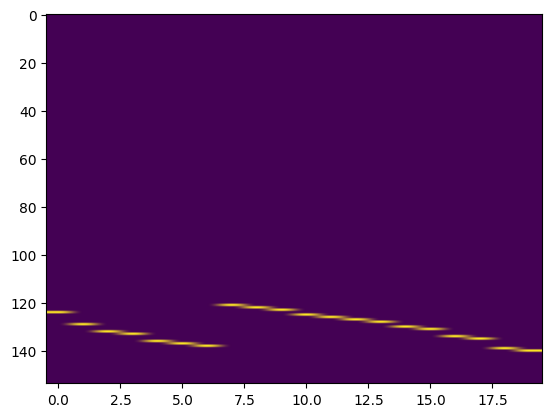

In [18]:
plt.imshow(data['Pin'].T, aspect='auto', cmap='viridis')

In [25]:
S = data['S']
np.linalg.matrix_rank(S)

np.int64(67)

In [26]:
U, D, V = np.linalg.svd(S)
U.shape, D.shape, V.shape


((72, 72), (72,), (154, 154))

In [29]:
D[-5:]

array([1.23806455e-14, 1.23806455e-14, 1.23806455e-14, 1.23806455e-14,
       1.23787885e-14])

In [30]:
def train_model(
    d_model=128,
    n_heads=8,
    n_layers=3,
    d_ff=640,
    num_epochs=100,
    learning_rate=0.001,
    dropout=0.02,
    output_sample_ratio=0.5
):
    start_time = time.time()

    model = FluxTransformer(
        vocab_size=len(input_cols)+len(output_cols),
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout
    ).to(device)
    
    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.98),
        eps=1e-9,
        weight_decay=1e-4
    )
    criterion = nn.HuberLoss()

    best_test_loss = float('inf')
    best_epoch = -1

    train_losses = []
    test_losses = []

    total_outputs = len(output_cols)
    output_start_idx = len(input_cols)

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()

            # Randomly sample subset of outputs
            if output_sample_ratio >= 1.0:
                sampled_indices = None  # pass None to FluxTransformer.forward()
            else:
                n_sampled = max(1, int(total_outputs * output_sample_ratio))
                sampled_indices = torch.tensor(
                    random.sample(range(output_start_idx, output_start_idx + total_outputs), n_sampled),
                    device=device
                )

            #print(batch_X.size(),batch_y.size())
            
            predictions, selected_indices = model(batch_X, output_subset=sampled_indices)
            
            target = batch_y[:, selected_indices, :]
            
            # print(predictions.size(),target.size())
            # print(predictions[:,:,-1].unsqueeze(2).size(),target.size())

            loss = criterion(predictions[:,:,-1].unsqueeze(2), target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0)

            # Explicitly free tensors
            del predictions, loss
            if device.type == 'cuda':
                torch.cuda.empty_cache()
            elif device.type == 'mps':
                torch.mps.empty_cache()
        
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Evaluation
        model.eval()
        epoch_test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                n_sampled = max(1, int(total_outputs * output_sample_ratio))
                sampled_indices = torch.tensor(
                    random.sample(range(output_start_idx, output_start_idx + total_outputs), n_sampled),
                    device=device
                )

                predictions, selected_indices = model(batch_X, output_subset=sampled_indices)
                target = batch_y[:, selected_indices, :]
                loss = criterion(predictions[:,:,-1].unsqueeze(2), target)

                epoch_test_loss += loss.item() * batch_X.size(0)

                # Explicitly free tensors
                del predictions, loss
                if device.type == 'cuda':
                    torch.cuda.empty_cache()
                elif device.type == 'mps':
                    torch.mps.empty_cache()
        
        epoch_test_loss /= len(test_loader.dataset)
        test_losses.append(epoch_test_loss)

        if (epoch+1) % 2 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {epoch_train_loss:.6f} | "
                f"Test Loss: {epoch_test_loss:.6f}")
        
        if epoch_test_loss < best_test_loss:
            best_test_loss = epoch_test_loss
            best_epoch = epoch + 1
        
        # Additional memory cleanup after epoch
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        elif device.type == 'mps':
            torch.mps.empty_cache()
        gc.collect()

    print('Training Completed.')
    end_time = time.time()
    elapsed_time = end_time - start_time
    mins, secs = divmod(elapsed_time, 60)
    print(f"Training took {int(mins)} min {secs:.1f} sec.")
    print(f"Best test loss: {best_test_loss:.6f} at epoch {best_epoch}")
    
    return train_losses, test_losses, model, optimizer

### Plotting Functions

In [31]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [32]:
def plot_diagnostics_2x2(y_true, y_pred, label):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples"""
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

In [33]:
def plot_prediction_sample(X_test, y_test, model):
    X_test_ = X_test.unsqueeze(-1)
    y_test_ = y_test.unsqueeze(-1)
    j = np.random.randint(0, X_test_.size(0), 1)[0]
    with torch.no_grad():
        pred, _ = model(X_test_[j].unsqueeze(0))
    true = y_test_[j].unsqueeze(0)
    plt.plot(pred[0,:,-1].cpu().detach().numpy(), label='Predicted')
    plt.plot(true[0,:,0].cpu().detach().numpy(), label='True')

    # add a red vertical line at index 32 (biomass)
    plt.axvline(x=32, color='red', linestyle='--', linewidth=1)
    
    plt.legend()
    plt.title(f"Sample index {j}")
    plt.xlabel("Reaction ID")
    plt.ylabel("Rate")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [34]:
def plot_flux(
    model,
    X_test,
    y_test,
    output_cols,
    flux_name: str,
):
    """ Displays a 2x2 diagnostic plot for the chosen flux."""

    #model.eval()
    model_cpu = model.to('cpu')  # move model to CPU
    model_cpu.eval()

    with torch.no_grad():
        y_pred_tensor, _ = model_cpu(X_test.unsqueeze(-1).to('cpu'))  # shape: [n_samples, 115, 1]
        #y_pred_tensor = model(X_test.unsqueeze(-1).to(device))  # shape: [n_samples, 115, 1]

    y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 115]
    y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 115]

    # Extract only the output predictions (last 154 columns)
    y_pred_outputs = y_pred_full[:, 20:,-1]
    y_true_outputs = y_true_full[:, 20:]
    print("y_pred_outputs.shape:", y_pred_outputs.shape,
            "min/max:", y_pred_outputs.min(), y_pred_outputs.max())
    print("y_true_outputs.shape:", y_true_outputs.shape,
            "min/max:", y_true_outputs.min(), y_true_outputs.max())

    try:
        idx = output_cols.index(flux_name)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    # Verify the correct column
    print(f"{flux_name} index in outputs: {idx}")
    print(f"y_true_outputs[:, idx] range:",
            y_true_outputs[:, idx].min(), "to", y_true_outputs[:, idx].max())
    print(f"y_pred_outputs[:, _idx] range:",
            y_pred_outputs[:, idx].min(), "to", y_pred_outputs[:, idx].max())

    # Plot diagnostics specifically for given flux
    plot_diagnostics_2x2(
        y_true=y_true_outputs[:, idx],
        y_pred=y_pred_outputs[:, idx],
        label=flux_name
    )

In [36]:
def plot_output_ratio_metric(ratios, r2_values, flux_name, metric_name='r2', save_path=None):
    """
    Plot R² performance vs. output subset ratio.
    """
    plt.figure(figsize=(14, 10))
    plt.plot(ratios, r2_values, marker='o', linewidth=2)
    plt.xlabel('Output Subset Ratio', fontsize=18)
    plt.ylabel(metric_name.upper(), fontsize=18)
    plt.title(f'Impact of Output Subset Ratio on {flux_name} Prediction', fontsize=20)
    plt.grid(True)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlim(0, 1)
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"Saved output ratio plot to {save_path}")
        plt.close()
    else:
        plt.show()

### Effect of Output Subset Ratio

In [37]:
d_model = 128
n_heads = 8
n_layers = 3
d_ff = 640
batch_size = 128
num_epochs = 200
learning_rate = 1e-4
dropout = 0.02

In [38]:
def evaluate_metrics(model, X_test, y_test, output_cols, device='cpu', batch_size=16):
    """
    Evaluate a trained FluxTransformer model on test data.

    Args:
        model (nn.Module): Trained PyTorch model.
        X_test (Tensor): Test inputs, shape [n_samples, input+output features].
        y_test (Tensor): Test outputs, shape [n_samples, input+output features].
        output_cols (list of str): Names of output flux columns.
        device (str or torch.device): Device to run evaluation on.

    Returns:
        pd.DataFrame: DataFrame with columns ['flux', 'r2', 'mae'].
    """
    model = model.to(device)
    model.eval()

    y_preds = []
    y_trues = []
    
    n_samples = X_test.size(0)
    
    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            x_batch = X_test[start:end].unsqueeze(-1).to(device)
            y_batch = y_test[start:end].to(device)
            
            y_pred_tensor, _ = model(x_batch)
            y_preds.append(y_pred_tensor.squeeze(-1).cpu())
            y_trues.append(y_batch.cpu())
    
    y_pred = torch.cat(y_preds, dim=0).numpy()[:, 20:]  # skip input indices
    y_true = torch.cat(y_trues, dim=0).numpy()[:, 20:]

    metrics = []
    for i, label in enumerate(output_cols):
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        metrics.append({'flux': label.replace('_flux',''), 'r2': r2, 'mae': mae})

    df_metrics = pd.DataFrame(metrics)
    df_metrics['r2'] = df_metrics['r2'].map('{:.3f}'.format)
    df_metrics['mae'] = df_metrics['mae'].map('{:.4f}'.format)
    
    return df_metrics

In [39]:
def plot_constraint_and_mass_balance_diagnostics(model, X_test, y_test, input_cols, data):
    """
    Runs the model on test data and generates a 2x2 matrix of plots:
    1. Lower bound constraint violation heatmap
    2. Histogram of lower bound violations
    3. Mass balance violation heatmap
    4. Histogram of mass balance violations
    """
    import torch
    import matplotlib.pyplot as plt

    # Move model to CPU and set to eval mode
    model_cpu = model.to('cpu')
    model_cpu.eval()

    with torch.no_grad():
        y_pred_tensor, _ = model_cpu(X_test.unsqueeze(-1).to('cpu'))

    Pin = torch.tensor(data['Pin'], dtype=torch.float32)
    S = torch.tensor(data['S'], dtype=torch.float32)

    # Lower bound constraint violations
    Loss_Vin = torch.matmul(
        y_pred_tensor[:, len(input_cols):, :].permute(0, 2, 1).to('cpu'),
        Pin.T
    ) - X_test.to('cpu').unsqueeze(1)[:, :, :len(input_cols)]
    Loss_Vin_np = Loss_Vin.squeeze(1).cpu().numpy()

    # Mass balance constraint violations
    Loss_SV = torch.matmul(
        y_pred_tensor[:, len(input_cols):, :].permute(0, 2, 1).to('cpu'),
        S.T
    )
    Loss_SV_np = Loss_SV.cpu().numpy()

    fig, axs = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Lower bound constraint violation heatmap
    im1 = axs[0, 0].imshow(Loss_Vin_np[:, -1, :], aspect='auto', cmap='viridis')
    plt.colorbar(im1, ax=axs[0, 0], fraction=0.046, pad=0.04)
    axs[0, 0].set_title('Upper Bound Constraint Violations (Heatmap)')

    # Plot 2: Histogram of lower bound violations
    axs[0, 1].hist(Loss_Vin_np[:, -1, :].flatten(), bins=100, color='skyblue', edgecolor='black')
    axs[0, 1].set_title('Histogram of Upper Bound Constraint Violations (Loss_Vin)')
    axs[0, 1].set_xlabel('Loss_Vin Value')
    axs[0, 1].set_ylabel('Frequency')
    axs[0, 1].grid(True)

    # Plot 3: Mass balance violation heatmap
    im2 = axs[1, 0].imshow(Loss_SV_np[:, -1, :], aspect='auto', cmap='viridis')
    plt.colorbar(im2, ax=axs[1, 0], fraction=0.046, pad=0.04)
    axs[1, 0].set_title('Mass Balance Violations (Heatmap)')

    # Plot 4: Histogram of mass balance violations
    axs[1, 1].hist(Loss_SV_np[:, -1, :].flatten(), bins=100, color='skyblue', edgecolor='black')
    axs[1, 1].set_title('Histogram of Mass Balance Violations on Test Set')
    axs[1, 1].set_xlabel('Mass Balance Violation')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

In [121]:
def min_distance_to_null_space(S, v):
    """
    Computes the minimum Euclidean distance between a vector v and the null space of matrix S.
    Returns the distance and the closest vector in the null space.
    """
    # Compute the null space of S using SVD
    U, D, Vh = np.linalg.svd(S)
    tol = 1e-12
    null_mask = np.array([False for _ in range(S.size(1))])
    null_mask[:len(D)] = (D < tol)
    null_space = Vh.T[:, null_mask] if np.any(null_mask) else Vh.T[:, len(D):]

    if null_space.shape[1] == 0:
        raise ValueError("Matrix S has trivial null space (only zero vector).")

    # Project v onto the null space
    # Find coefficients c that minimize ||v - N c||^2
    N = null_space
    c = np.linalg.lstsq(N, v, rcond=None)[0]
    v_proj = N @ c

    # Minimum distance
    distance = np.linalg.norm(v - v_proj)
    return distance, v_proj

# Example usage:
# S = ... # your stoichiometric matrix
# v = ... # your vector
# dist, closest_vec = min_distance_to_null_space(S, v)
# print("Minimum distance:", dist)
# print("Closest vector in null space:", closest_vec)

In [109]:
U, D, Vh = np.linalg.svd(S)
tol = 1e-12
null_mask = np.array([False for _ in range(S.size(1))])
null_mask[:len(D)] = (D < tol)


In [125]:
S.size(1)

154

In [87]:
U.size()

torch.Size([72, 72])

In [90]:
D.shape

(72,)

In [91]:
Vh.size()

torch.Size([154, 154])

In [319]:
# biomass_col = 'Biomass_Ecoli_core_UB'

# ratios = np.arange(0.1, 1.1, 0.1)
# biomass_r2 = []
# biomass_mae = []

# for ratio in ratios:
#     print(f"\nTraining with output subset ratio = {ratio:.1f}")
    
#     # Train model with given output_sample_ratio
#     train_loss, test_loss, model, optimizer = train_model(
#         d_model=d_model,
#         n_heads=n_heads,
#         n_layers=n_layers,
#         d_ff=d_ff,
#         num_epochs=num_epochs,
#         learning_rate=learning_rate,
#         dropout=dropout,
#         output_sample_ratio=ratio
#     )
    
#     # Evaluate R² for biomass
#     df_metrics = evaluate_metrics(model, X_test, y_test, output_cols, device=device, batch_size=batch_size)
#     row = df_metrics.loc[df_metrics['flux'] == biomass_col.replace('_flux', '')].iloc[0]
    
#     r2_value = float(row['r2'])
#     mae_value = float(row['mae'])
    
#     biomass_r2.append(r2_value)
#     biomass_mae.append(mae_value)
    
#     # Free GPU memory
#     del model, optimizer, train_loss, test_loss
#     if device == 'cuda':
#         torch.cuda.empty_cache()
#         print("Cleared CUDA cache")
#     elif device == 'mps':
#         torch.mps.empty_cache()
#         print("Cleared MPS cache")
#     else:
#         print("CPU doesn't require cache clearing")
#     gc.collect()

In [ ]:
# plot_output_ratio_metric(ratios, biomass_r2, biomass_col, metric_name='r2')

In [ ]:
# plot_output_ratio_metric(ratios, biomass_mae, biomass_col, metric_name='mae')

### Exploring Model Variants

The following cells test multiple Transformer configurations with varying model sizes, attention heads, and feedforward dimensions. Each variant is trained, evaluated, and visualized to assess its performance and scalability.

In [40]:
output_sample_ratio = 1

diagnostics_to_plot = ['BIOMASS_Ecoli_core_w_GAM', 'GLUDy_for']

In [53]:

print_gpu_memory()

MPS Allocated memory: 34.99 MB
MPS Driver allocated memory: 75.42 MB


Epoch 2/200 | Train Loss: 3.747769 | Test Loss: 3.247989
Epoch 4/200 | Train Loss: 2.260081 | Test Loss: 1.902859
Epoch 6/200 | Train Loss: 1.408183 | Test Loss: 1.348354
Epoch 8/200 | Train Loss: 1.312945 | Test Loss: 1.277967
Epoch 10/200 | Train Loss: 1.249506 | Test Loss: 1.207328
Epoch 12/200 | Train Loss: 1.157034 | Test Loss: 1.079651
Epoch 14/200 | Train Loss: 1.023816 | Test Loss: 0.950987
Epoch 16/200 | Train Loss: 0.978521 | Test Loss: 0.918187
Epoch 18/200 | Train Loss: 0.948826 | Test Loss: 0.894692
Epoch 20/200 | Train Loss: 0.922097 | Test Loss: 0.866023
Epoch 22/200 | Train Loss: 0.892102 | Test Loss: 0.834926
Epoch 24/200 | Train Loss: 0.861930 | Test Loss: 0.805968
Epoch 26/200 | Train Loss: 0.839891 | Test Loss: 0.791234
Epoch 28/200 | Train Loss: 0.813157 | Test Loss: 0.751290
Epoch 30/200 | Train Loss: 0.762193 | Test Loss: 0.694874
Epoch 32/200 | Train Loss: 0.721845 | Test Loss: 0.655496
Epoch 34/200 | Train Loss: 0.690378 | Test Loss: 0.624288
Epoch 36/200 | Tra

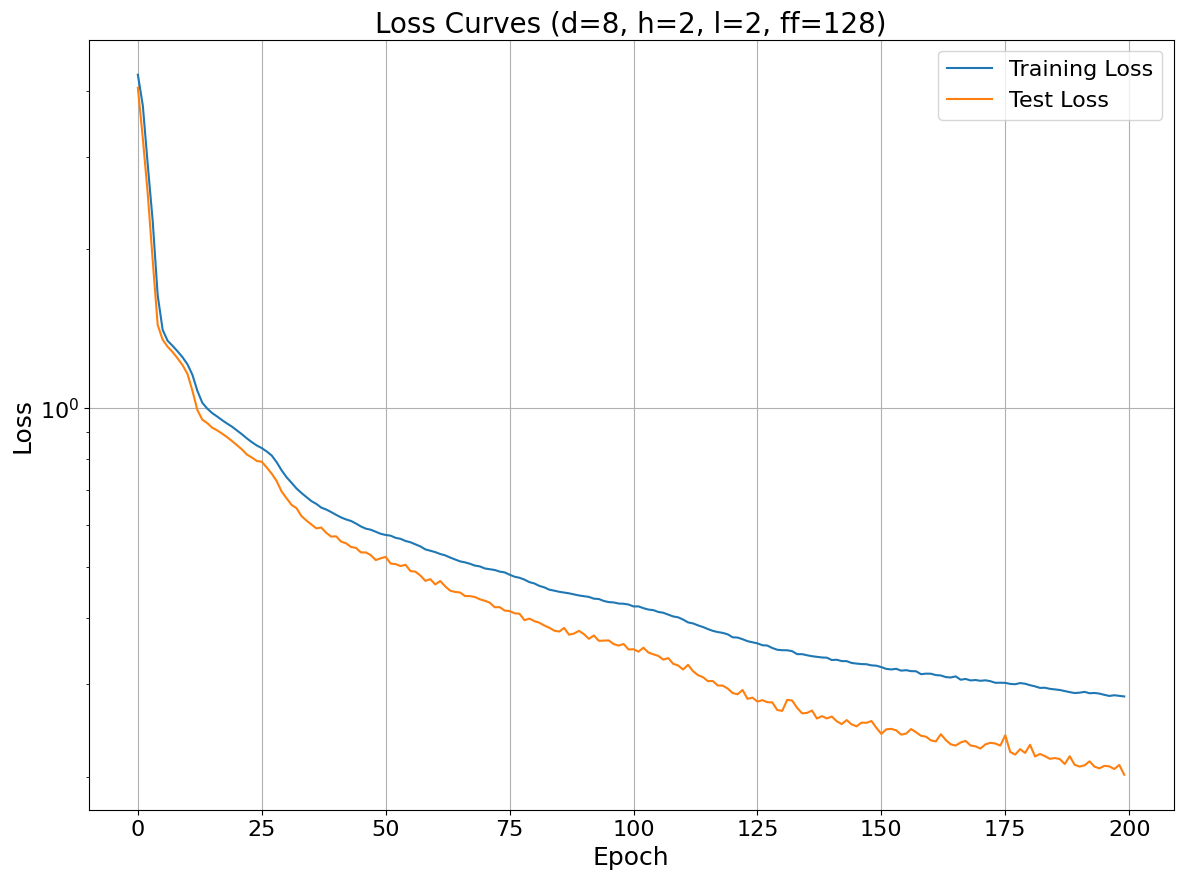

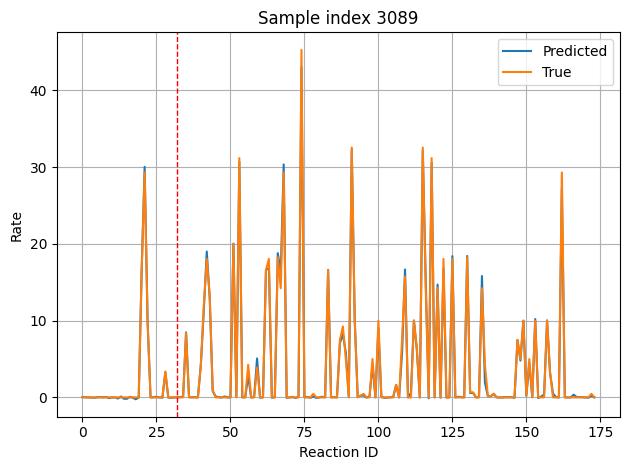

y_pred_outputs.shape: (6160, 154) min/max: -4.2448425 80.56266
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: 0.5590506 to 1.2481481
y_pred_outputs[:, _idx] range: 0.50284696 to 1.1517408


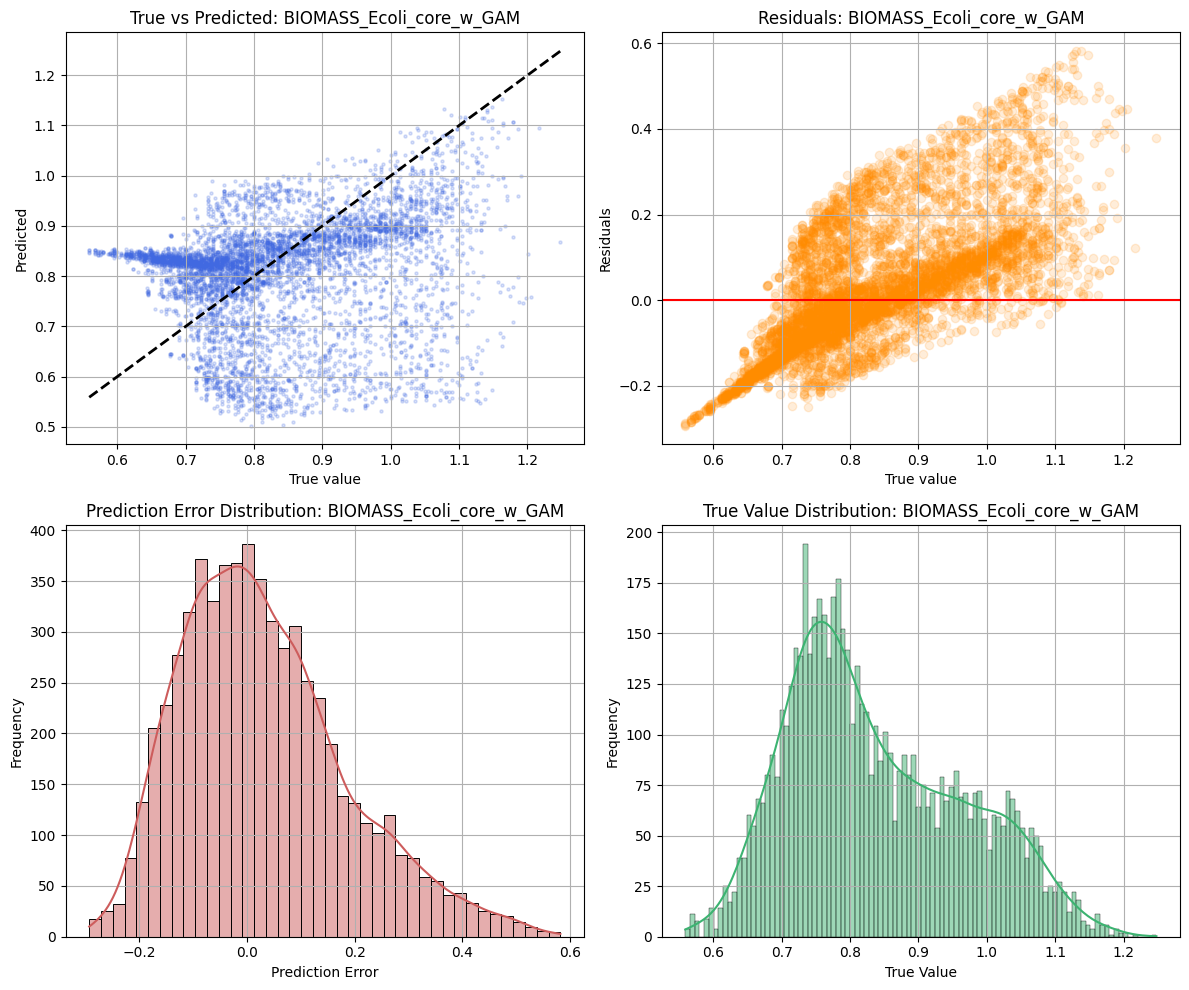

y_pred_outputs.shape: (6160, 154) min/max: -4.2448425 80.56266
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: 0.0 to 5.187185
y_pred_outputs[:, _idx] range: -0.013985217 to 0.41246223


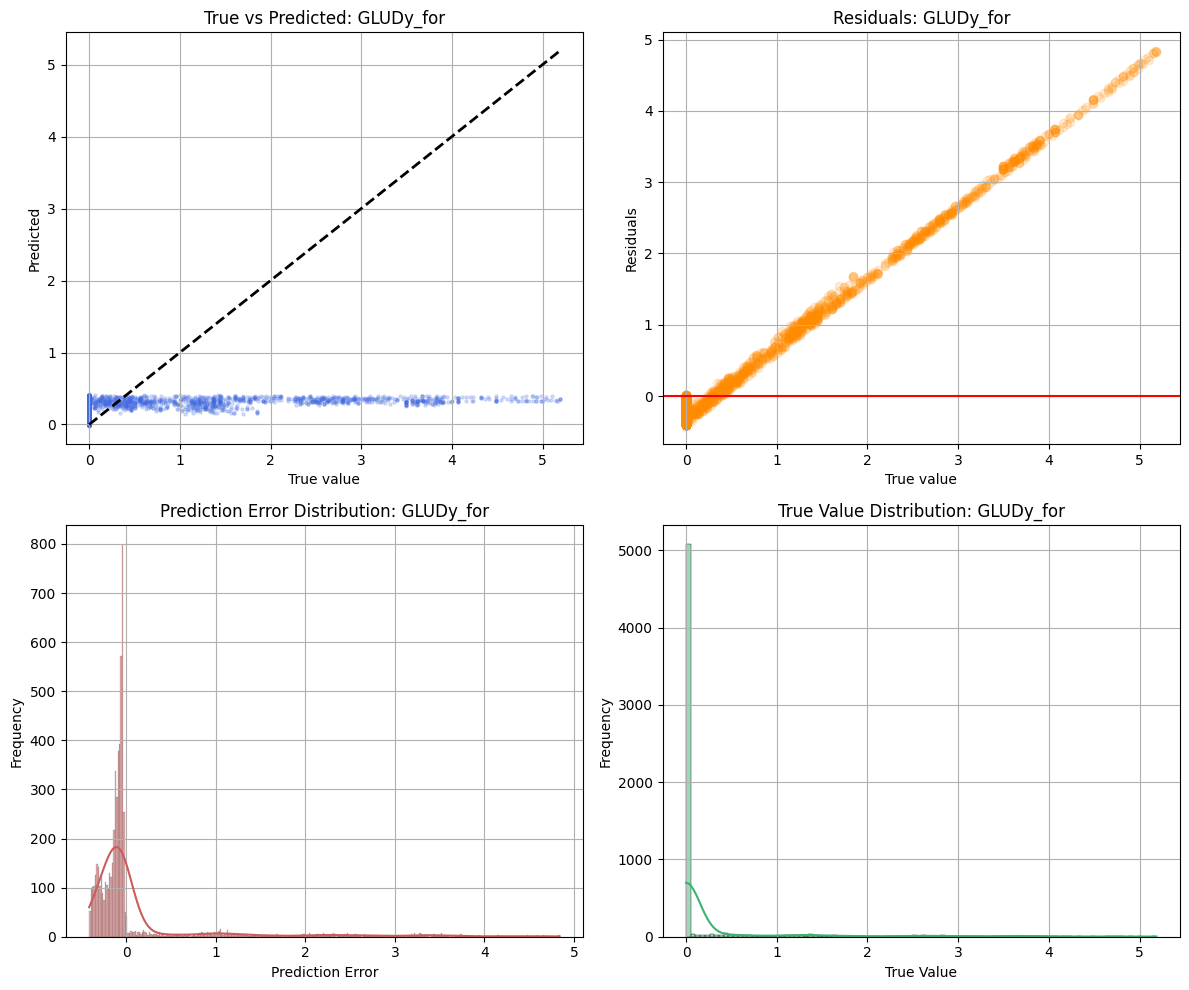

Number of parameters:
6922


In [42]:
train_losses, test_losses, model_822, optimizer = train_model(d_model=8, n_heads=2, n_layers=2, d_ff=128, num_epochs=num_epochs, dropout=dropout,output_sample_ratio=output_sample_ratio)

plot_loss_curves(train_losses, test_losses, d_model=8, n_heads=2, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_822)

for flux_name in diagnostics_to_plot:
    plot_flux(model_822, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_822.parameters() if p.requires_grad ))

In [43]:
model_822.to('mps:0');


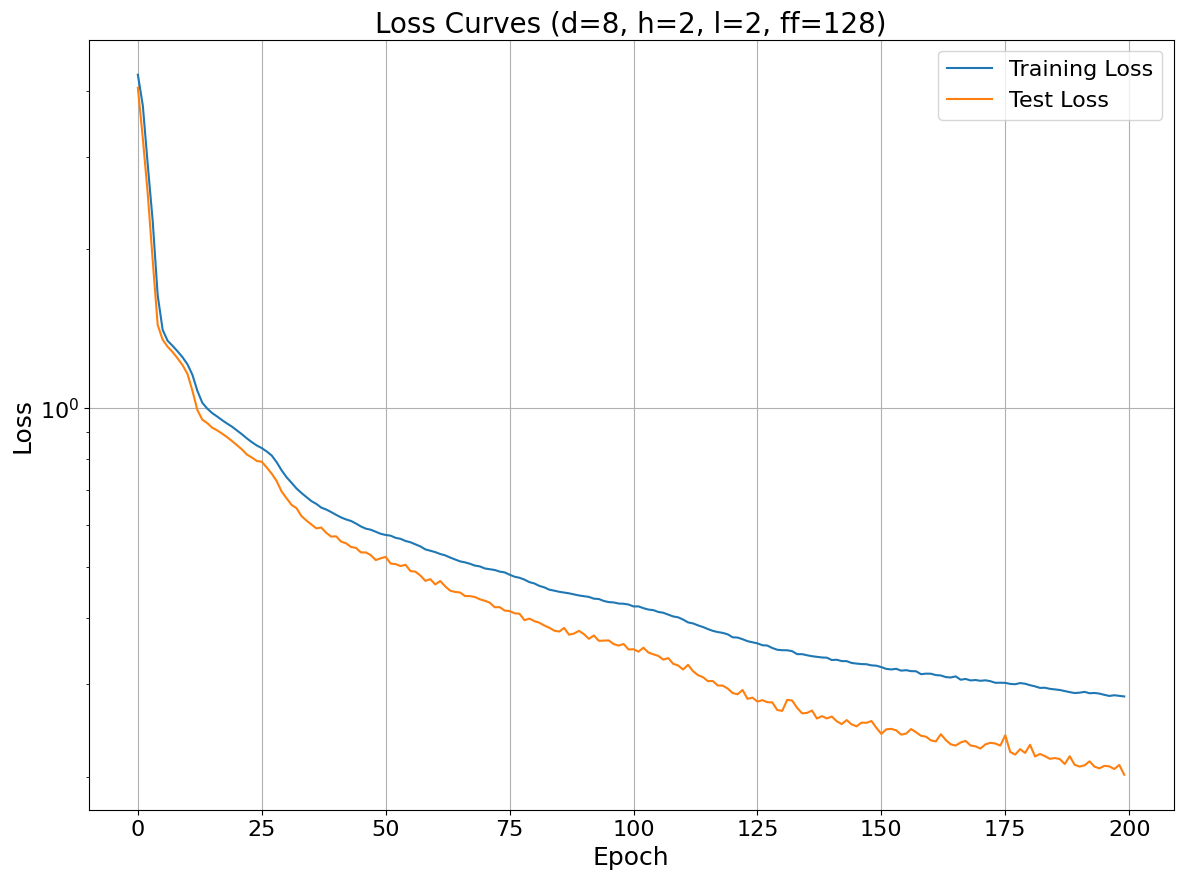

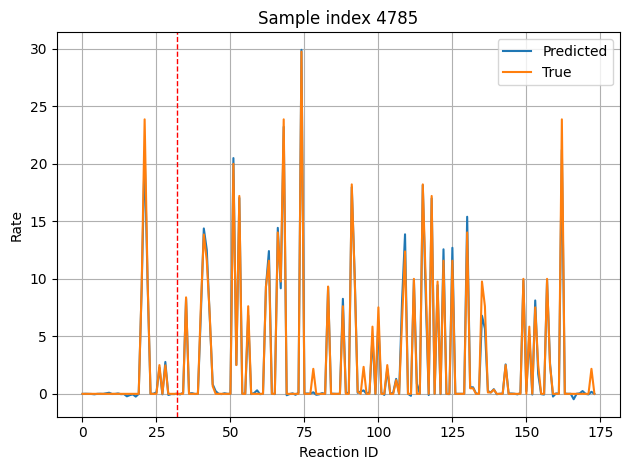

y_pred_outputs.shape: (6160, 154) min/max: -4.2448425 80.56266
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: 0.5590506 to 1.2481481
y_pred_outputs[:, _idx] range: 0.50284696 to 1.1517408


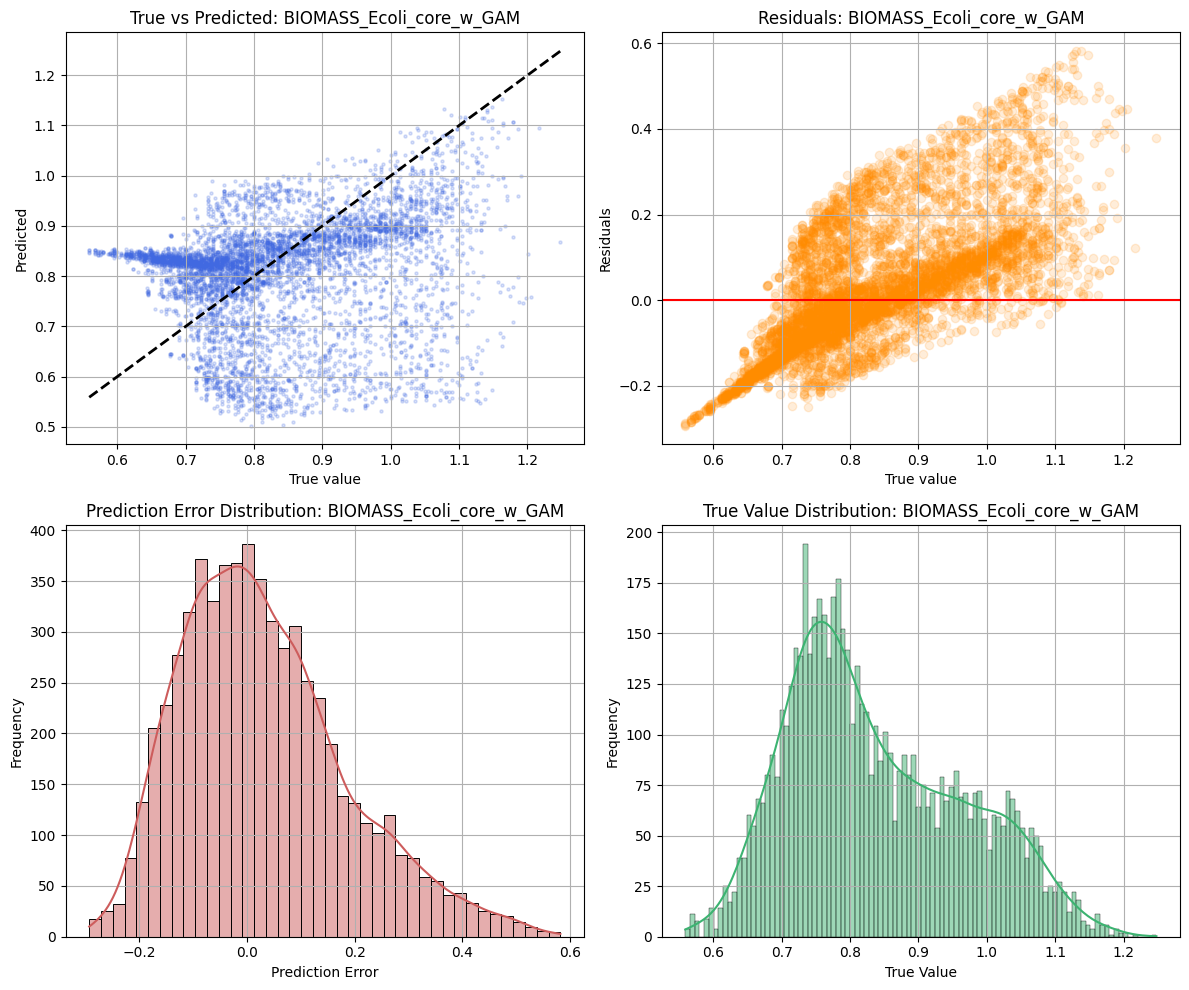

y_pred_outputs.shape: (6160, 154) min/max: -4.2448425 80.56266
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: 0.0 to 5.187185
y_pred_outputs[:, _idx] range: -0.013985217 to 0.41246223


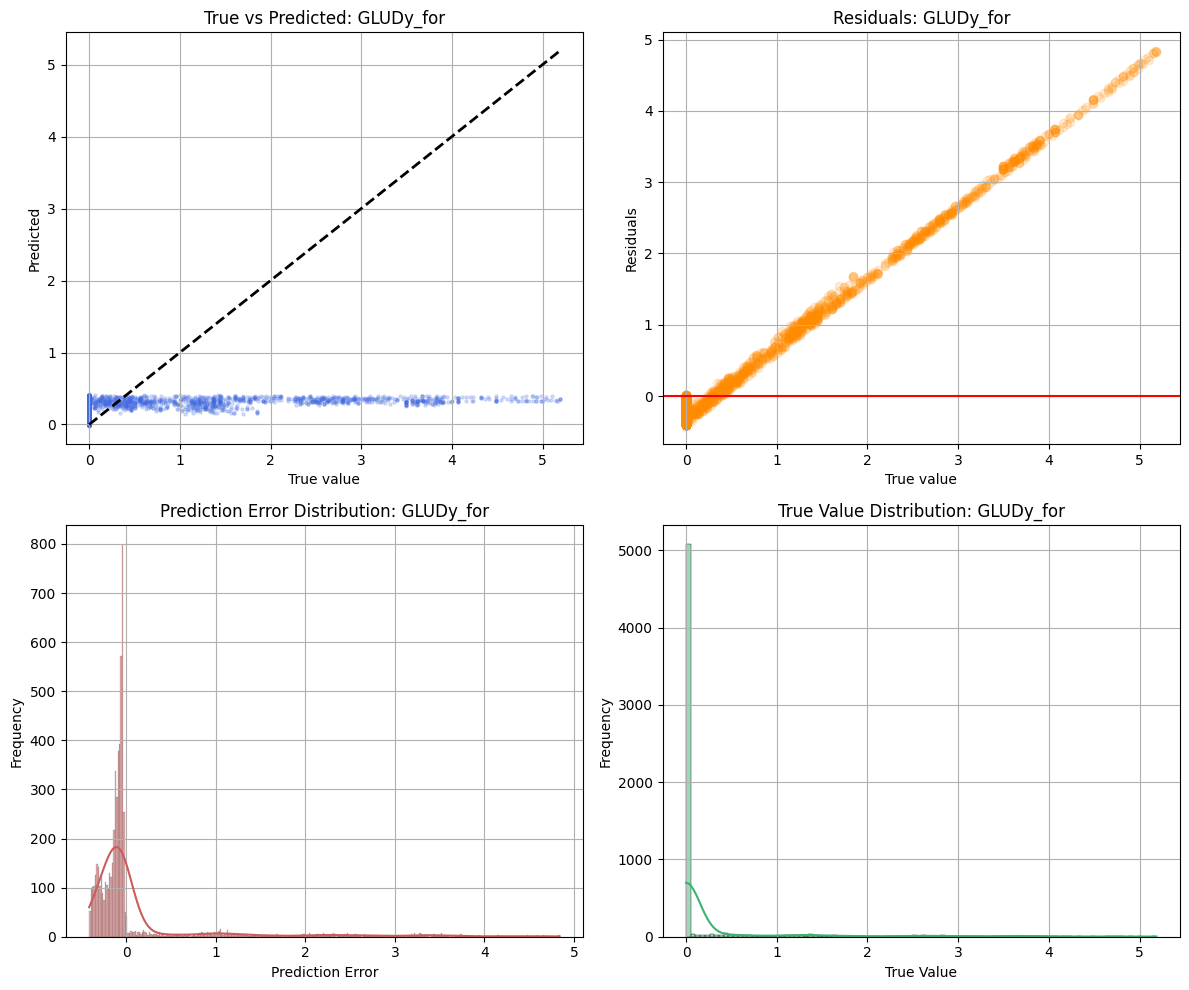

Number of parameters:
6922


In [44]:
plot_loss_curves(train_losses, test_losses, d_model=8, n_heads=2, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_822)

for flux_name in diagnostics_to_plot:
    plot_flux(model_822, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_822.parameters() if p.requires_grad ))

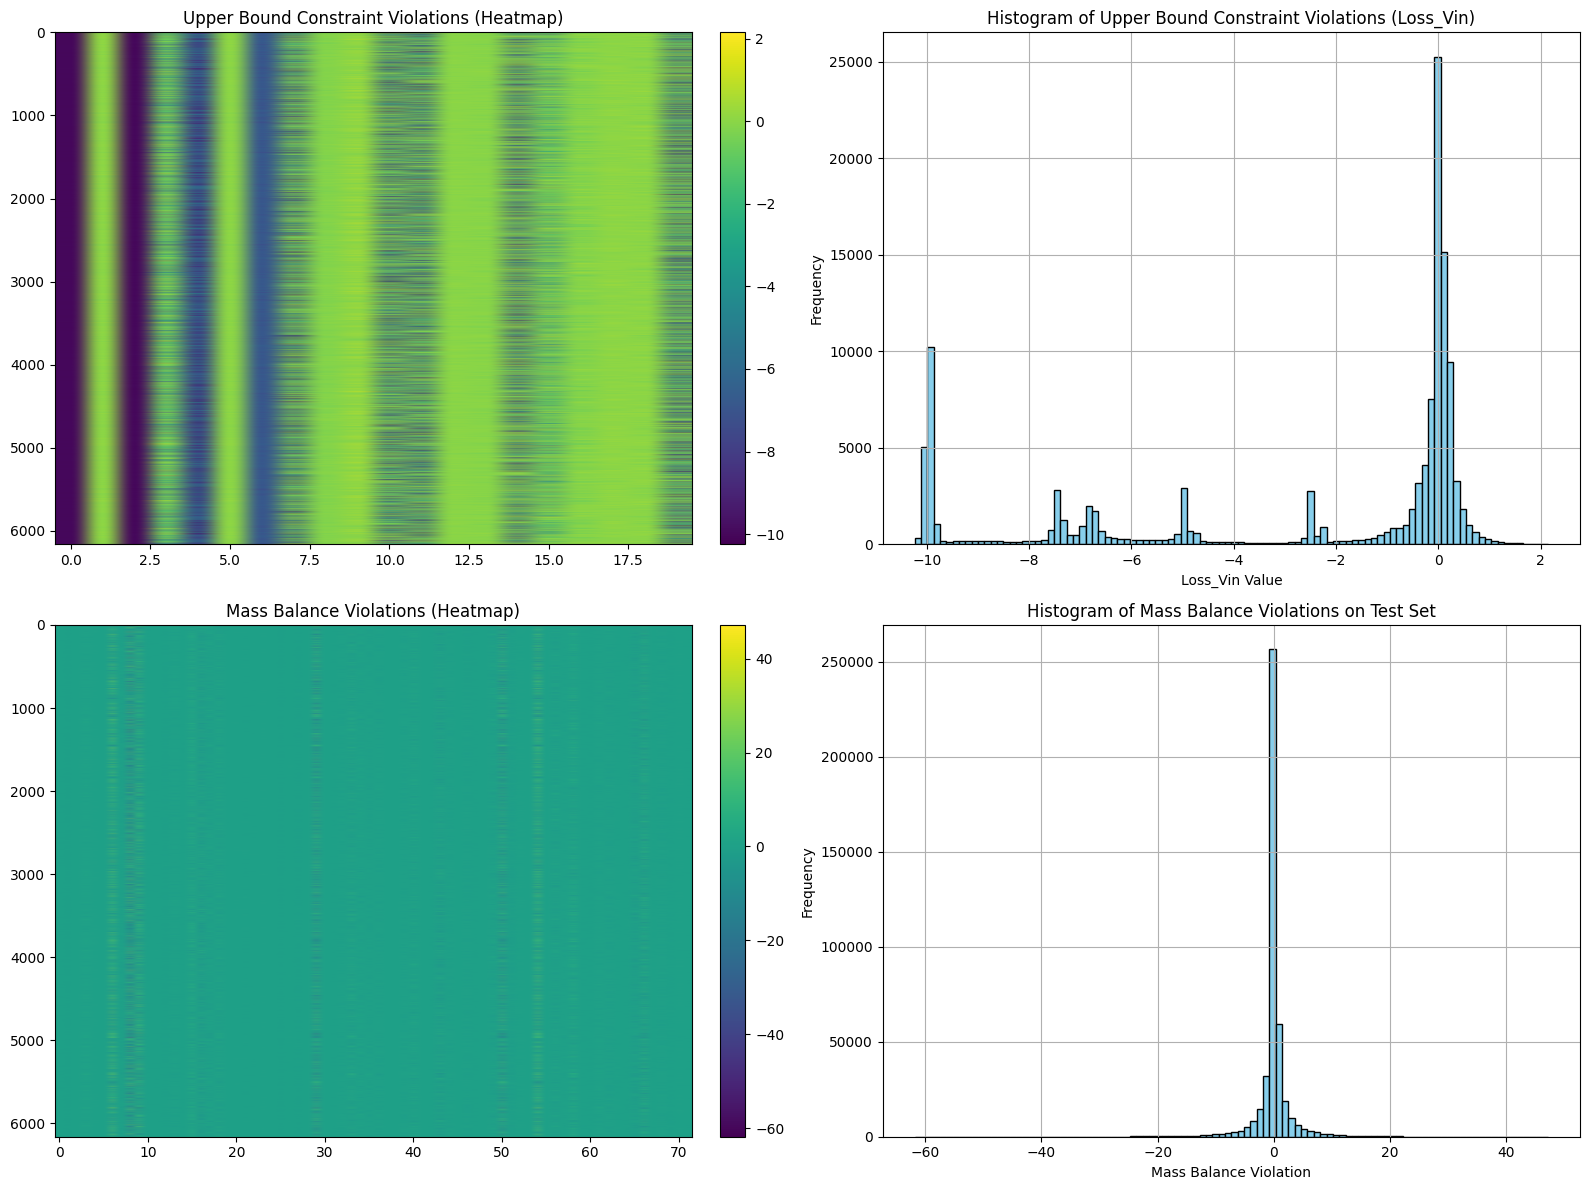

In [45]:
plot_constraint_and_mass_balance_diagnostics(model_822, X_test, y_test, input_cols, data)

In [304]:
# model_822_cpu = model_822.to('cpu')  # move model to CPU
# model_822_cpu.eval()

# with torch.no_grad():
#     y_pred_tensor, _ = model_822_cpu(X_test.unsqueeze(-1).to('cpu'))  # shape: [n_samples, 174, 1]
#     #y_pred_tensor = model(X_test.unsqueeze(-1).to(device))  # shape: [n_samples, 174, 1]

# y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 174]
# y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 174]

In [305]:
# # Check lower bound constraint violations on test set, Loss_Vin

# Pin = torch.tensor(data['Pin'], dtype=torch.float32)  

# Loss_Vin = torch.matmul(y_pred_tensor[:,len(input_cols):,:].permute(0,2,1).to('cpu'), Pin.T) -X_test.to('cpu').unsqueeze(1)[:,:,:len(input_cols)] # shape: [n_samples, num_constraints]


In [306]:
# Loss_Vin.size()

In [307]:
# Loss_Vin_np = Loss_Vin.squeeze(1).cpu().numpy()  # shape: [n_samples, num_constraints]

In [308]:
# plt.imshow(Loss_Vin_np[:,-1,:], aspect='auto', cmap='viridis')
# plt.colorbar(label='Lower bound Check (must be >= 0)')

In [309]:
# # Histogram of lower bound violations
# plt.figure(figsize=(10,6))
# plt.hist(Loss_Vin_np[:,-1,:].flatten(), bins=100, color='skyblue', edgecolor='black')
# plt.title('Histogram of Lower Bound Constraint Violations (Loss_Vin)')
# plt.xlabel('Loss_Vin Value')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.show()


In [ ]:
# # Check Stochastic Mass Balance constraints on test set, Loss_SV

# S = torch.tensor(data['S'], dtype=torch.float32)  # Stoichiometric matrix
# Loss_SV = torch.matmul(y_pred_tensor[:,len(input_cols):,:].permute(0,2,1).to('cpu'), S.T)  # shape: [n_samples, num_metabolites]

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 2 is not equal to len(dims) = 3

In [ ]:
# torch.linalg.norm(Loss_SV[:,1,:])

tensor(2005.7177)

In [311]:
# Loss_SV.size()

In [312]:
# # Plot each of the mass balance violations
# Loss_SV_np = Loss_SV.cpu().numpy()  # shape: [n_samples, num_metabolites]    
# plt.imshow(Loss_SV_np[:,-1,:],aspect='auto', cmap='viridis')
# plt.colorbar(label='Mass Balance Check (must be ~ 0)')

In [313]:
# # Histogram of mass balance violations
# plt.figure(figsize=(10,6))
# plt.hist(Loss_SV_np[:,-1,:].flatten(), bins=100, color='skyblue', edgecolor='black')
# plt.title('Histogram of Mass Balance Violations on Test Set')
# plt.xlabel('Mass Balance Violation')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.show()

Epoch 2/200 | Train Loss: 3.461667 | Test Loss: 3.127603
Epoch 4/200 | Train Loss: 2.154795 | Test Loss: 1.830531
Epoch 4/200 | Train Loss: 2.154795 | Test Loss: 1.830531
Epoch 6/200 | Train Loss: 1.386328 | Test Loss: 1.320554
Epoch 6/200 | Train Loss: 1.386328 | Test Loss: 1.320554
Epoch 8/200 | Train Loss: 1.216351 | Test Loss: 1.166363
Epoch 8/200 | Train Loss: 1.216351 | Test Loss: 1.166363
Epoch 10/200 | Train Loss: 1.152916 | Test Loss: 1.097158
Epoch 10/200 | Train Loss: 1.152916 | Test Loss: 1.097158
Epoch 12/200 | Train Loss: 1.068434 | Test Loss: 1.037369
Epoch 12/200 | Train Loss: 1.068434 | Test Loss: 1.037369
Epoch 14/200 | Train Loss: 1.012191 | Test Loss: 1.031648
Epoch 14/200 | Train Loss: 1.012191 | Test Loss: 1.031648
Epoch 16/200 | Train Loss: 1.022547 | Test Loss: 0.980936
Epoch 16/200 | Train Loss: 1.022547 | Test Loss: 0.980936
Epoch 18/200 | Train Loss: 1.004593 | Test Loss: 1.014770
Epoch 18/200 | Train Loss: 1.004593 | Test Loss: 1.014770
Epoch 20/200 | Train 

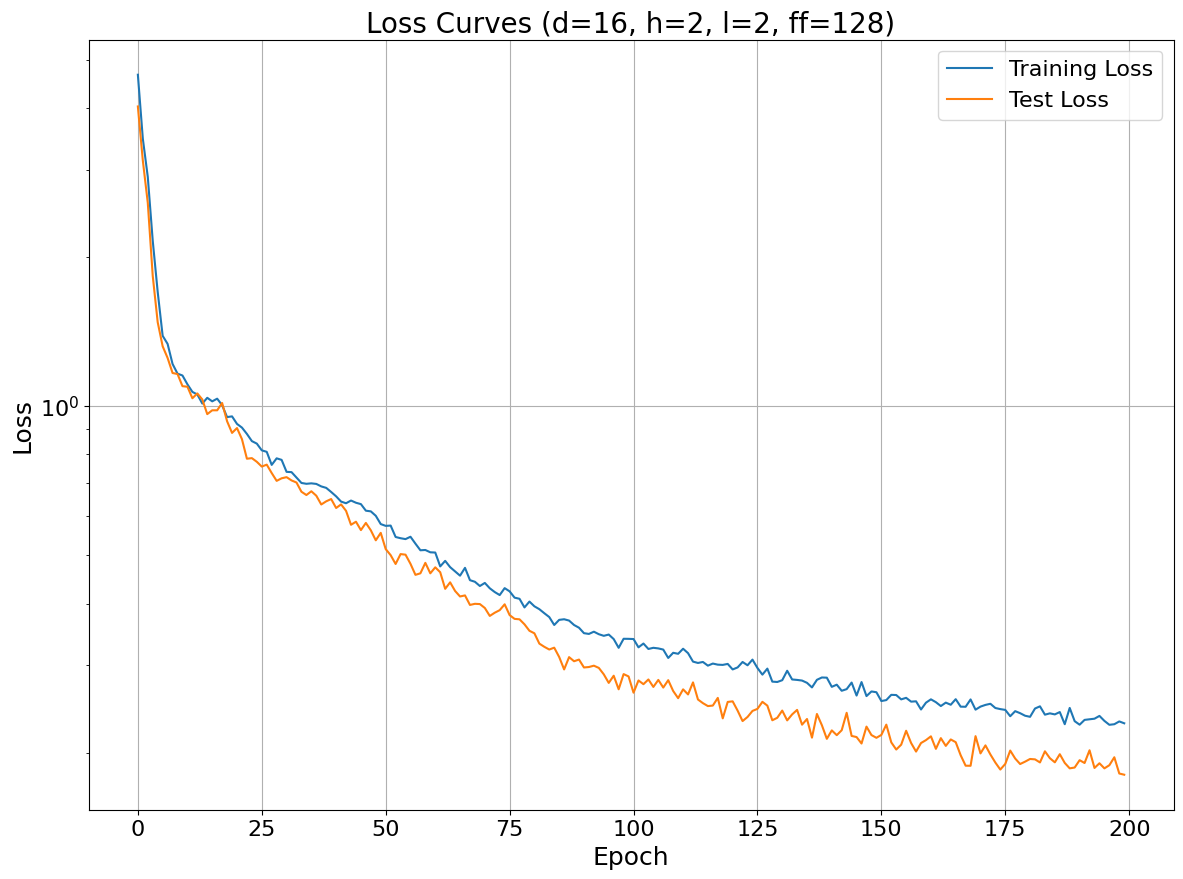

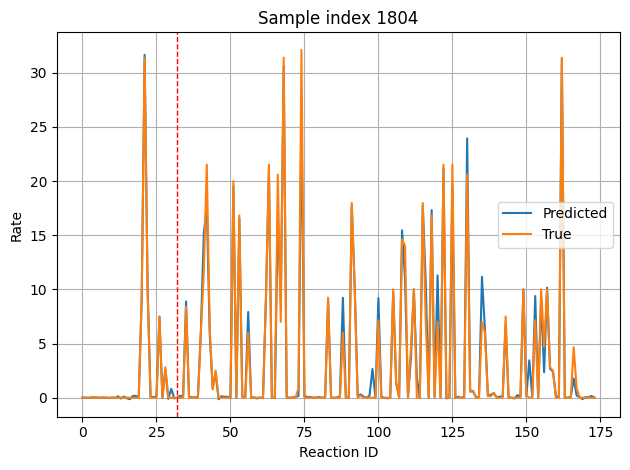

y_pred_outputs.shape: (6160, 154) min/max: -1.8265104 77.44516
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: 0.5590506 to 1.2481481
y_pred_outputs[:, _idx] range: 0.7583932 to 1.1727278


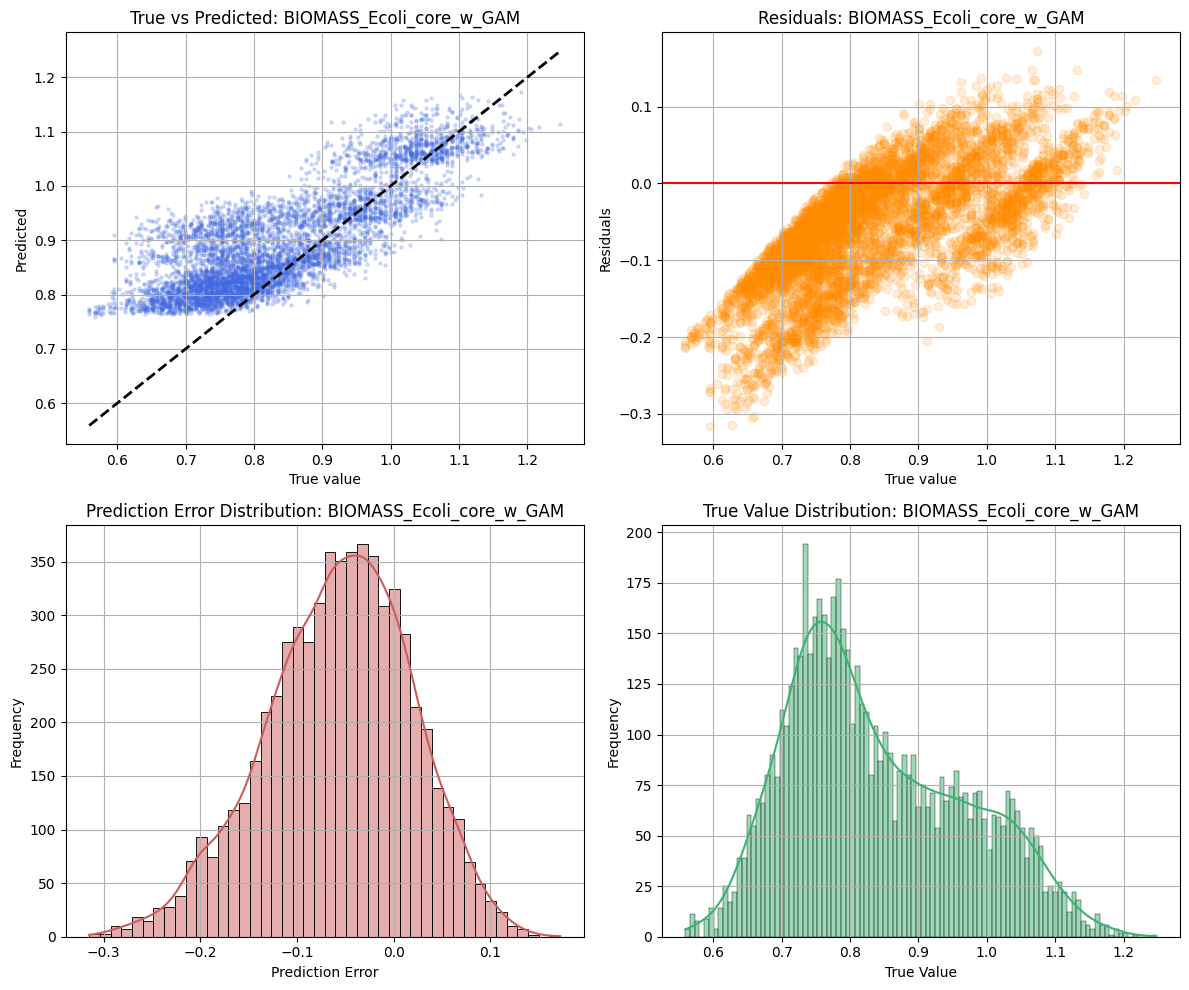

y_pred_outputs.shape: (6160, 154) min/max: -1.8265104 77.44516
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: 0.0 to 5.187185
y_pred_outputs[:, _idx] range: -0.47176224 to 3.4453533


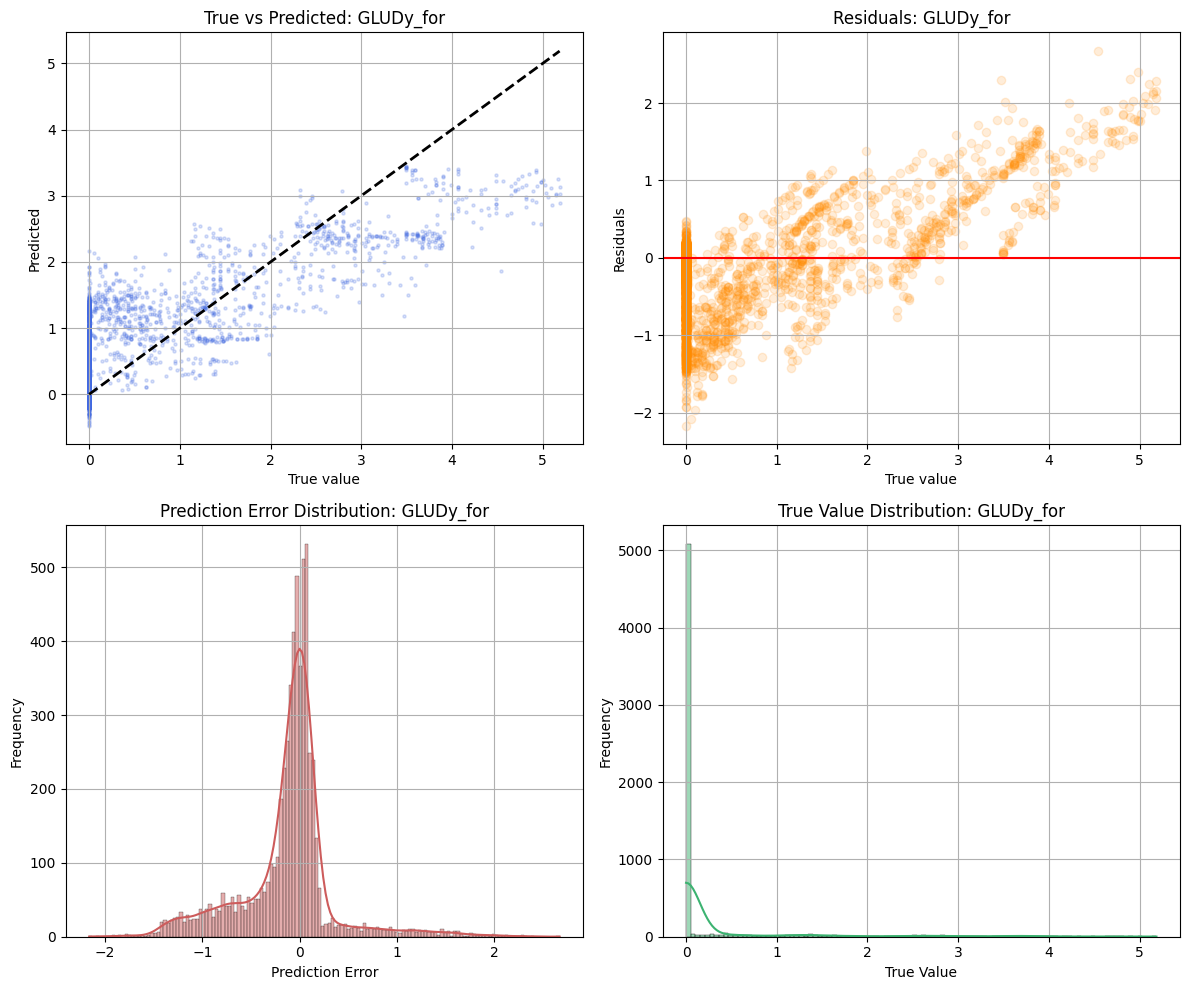

Number of parameters:
14090


In [46]:
train_losses_1622, test_losses_1622, model_1622, optimizer = train_model(d_model=16, n_heads=2, n_layers=2, d_ff=128, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_1622, test_losses_1622, d_model=16, n_heads=2, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_1622)

for flux_name in diagnostics_to_plot:
    plot_flux(model_1622, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_1622.parameters() if p.requires_grad ))

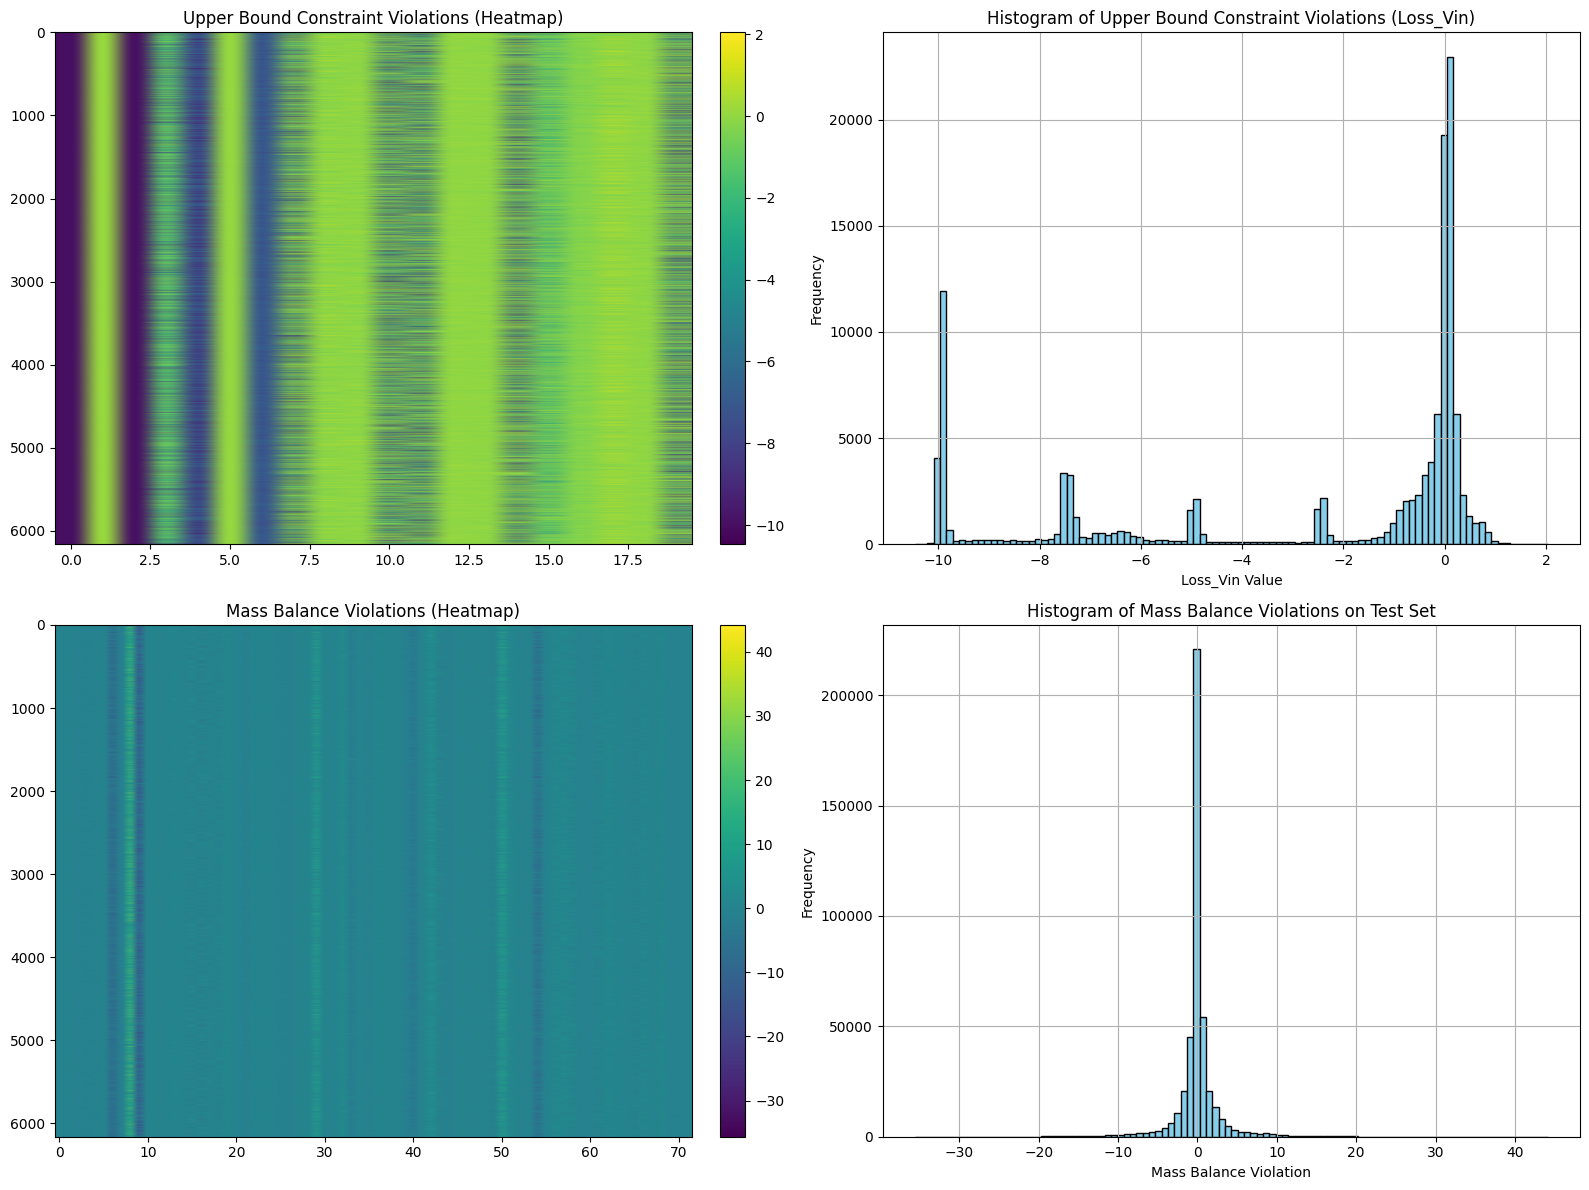

In [48]:
plot_constraint_and_mass_balance_diagnostics(model_1622, X_test, y_test, input_cols, data)

In [155]:
model_1622_cpu = model_1622.to('cpu')  # move model to CPU
model_1622_cpu.eval()

with torch.no_grad():
    y_pred_tensor, _ = model_1622_cpu(X_test.unsqueeze(-1).to('cpu'))  # shape: [n_samples, 174, 1]
    #y_pred_tensor = model(X_test.unsqueeze(-1).to(device))  # shape: [n_samples, 174, 1]

y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 174]
y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 174]

# Check Stochastic Mass Balance constraints on test set, Loss_SV

S = torch.tensor(data['S'], dtype=torch.float32)  # Stoichiometric matrix
Loss_SV = torch.matmul(y_pred_tensor[:,len(input_cols):,:].permute(0,2,1).to('cpu'), S.T)  # shape: [n_samples, num_metabolites]

y_hat = y_pred_tensor[:,len(input_cols):,:].cpu().numpy()

U, D, Vh = np.linalg.svd(S)
tol = 1e-12
null_mask = np.array([False for _ in range(S.size(1))])
null_mask[:len(D)] = (D < tol)
null_space = Vh.T[:, null_mask] if np.any(null_mask) else Vh.T[:, len(D):]


if null_space.shape[1] == 0:
    raise ValueError("Matrix S has trivial null space (only zero vector).")

# Project v onto the null space
# Find coefficients c that minimize ||v - N c||^2
N = null_space
c = np.linalg.lstsq(N, y_hat[:,:,0].T, rcond=None)[0]
v_proj = N @ c

# Minimum distance
distance = np.linalg.norm(y_hat[:,:,0].T - v_proj.numpy())

print(distance)

1103.4348


/var/folders/d4/c0k1vj_n1ldckglybdhfrtsxmjh287/T/ipykernel_45232/1719860621.py:32: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  v_proj = N @ c


In [ ]:

# torch.linalg.norm(Loss_SV[:,0,:])



tensor([-6.7533e-01, -6.1607e-02, -1.1674e-01,  5.1336e-02,  2.2117e-01,
         2.9085e-02, -6.7138e-01,  3.2718e-02, -4.6834e-01,  3.6715e-01,
         1.7684e-01,  3.1434e-02, -9.8747e-03,  2.6483e-01,  6.2718e-02,
        -6.8132e-03,  6.8133e-03, -2.4924e-02,  2.4924e-02,  2.0337e-01,
         5.0318e-02, -2.9731e-02,  1.3816e-03,  9.3318e-02, -5.7674e-04,
        -1.0086e-01, -1.5850e-02, -3.6796e-01,  1.3034e-01, -8.2516e-02,
        -1.7273e-01,  4.1674e-02, -1.7571e-01,  6.9992e-02, -1.2321e-01,
         4.9269e-02, -4.9269e-02,  5.8371e-02, -4.7379e-02, -8.6898e-02,
        -2.6539e-01, -2.0612e-01,  3.2586e-01,  2.0027e-01,  2.1352e-01,
        -1.9022e-01,  4.3453e-02, -2.5775e-01,  5.6041e-02,  1.4057e-01,
        -2.5390e-01, -4.2659e-01,  1.4996e-01,  4.7322e-02,  2.0657e-01,
         2.4361e-01, -1.7190e-01, -8.5023e-02, -2.4372e-01,  3.2629e-02,
         4.8165e-02, -5.3429e-02,  5.6392e-02,  4.1074e-01,  1.8038e-01,
        -2.0521e-02, -1.8377e-02,  2.6293e-02, -2.0

In [146]:
y_hat.shape

(6160, 154, 2)

In [ ]:
# U, D, Vh = np.linalg.svd(S)
# tol = 1e-12
# null_mask = np.array([False for _ in range(S.size(1))])
# null_mask[:len(D)] = (D < tol)
# null_space = Vh.T[:, null_mask] if np.any(null_mask) else Vh.T[:, len(D):]



In [157]:
# if null_space.shape[1] == 0:
#     raise ValueError("Matrix S has trivial null space (only zero vector).")

# # Project v onto the null space
# # Find coefficients c that minimize ||v - N c||^2
# N = null_space
# c = np.linalg.lstsq(N, y_hat[:,:,0].T, rcond=None)[0]
# v_proj = N @ c

# # Minimum distance
# distance = np.linalg.norm(y_hat[:,:,0].T - v_proj.numpy())

Epoch 2/200 | Train Loss: 2.866432 | Test Loss: 2.257676
Epoch 4/200 | Train Loss: 1.579351 | Test Loss: 1.431142
Epoch 4/200 | Train Loss: 1.579351 | Test Loss: 1.431142
Epoch 6/200 | Train Loss: 1.230121 | Test Loss: 1.220351
Epoch 6/200 | Train Loss: 1.230121 | Test Loss: 1.220351
Epoch 8/200 | Train Loss: 1.147415 | Test Loss: 1.076030
Epoch 8/200 | Train Loss: 1.147415 | Test Loss: 1.076030
Epoch 10/200 | Train Loss: 0.981915 | Test Loss: 0.902624
Epoch 10/200 | Train Loss: 0.981915 | Test Loss: 0.902624
Epoch 12/200 | Train Loss: 0.831246 | Test Loss: 0.781034
Epoch 12/200 | Train Loss: 0.831246 | Test Loss: 0.781034
Epoch 14/200 | Train Loss: 0.692135 | Test Loss: 0.618875
Epoch 14/200 | Train Loss: 0.692135 | Test Loss: 0.618875
Epoch 16/200 | Train Loss: 0.604085 | Test Loss: 0.554155
Epoch 16/200 | Train Loss: 0.604085 | Test Loss: 0.554155
Epoch 18/200 | Train Loss: 0.570298 | Test Loss: 0.515898
Epoch 18/200 | Train Loss: 0.570298 | Test Loss: 0.515898
Epoch 20/200 | Train 

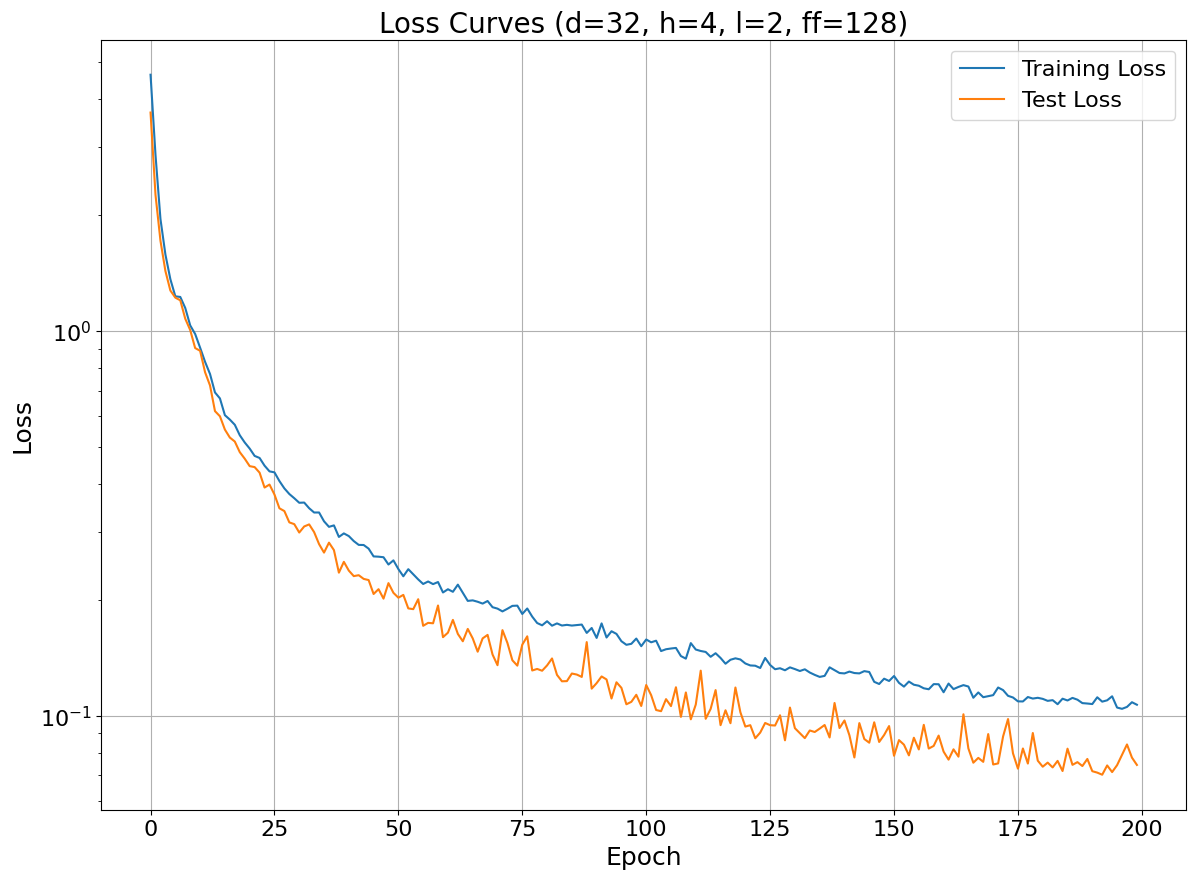

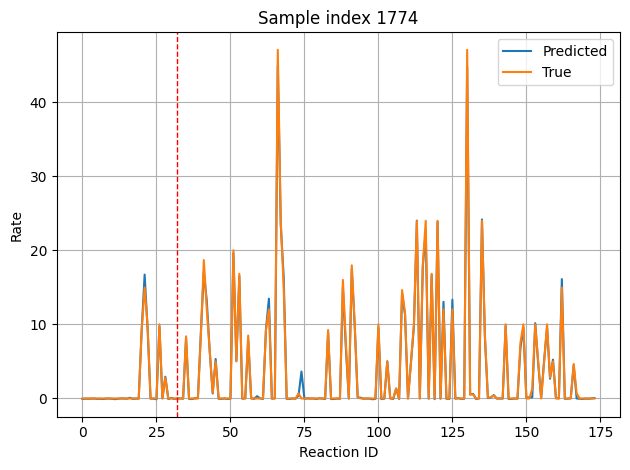

y_pred_outputs.shape: (6160, 154) min/max: -1.6993364 77.20587
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: 0.5590506 to 1.2481481
y_pred_outputs[:, _idx] range: 0.57896996 to 1.2313681


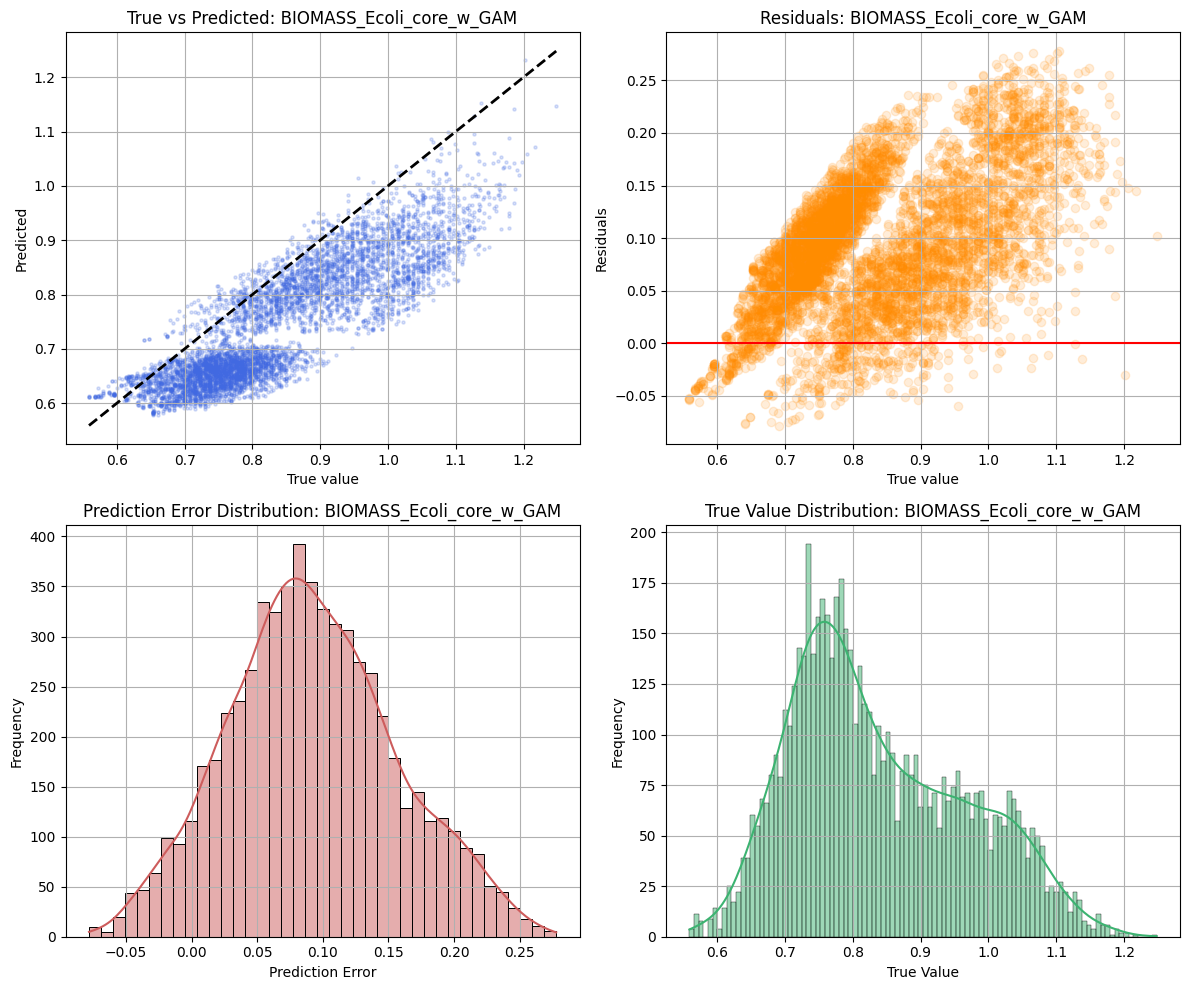

y_pred_outputs.shape: (6160, 154) min/max: -1.6993364 77.20587
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: 0.0 to 5.187185
y_pred_outputs[:, _idx] range: -0.1216594 to 3.8930545


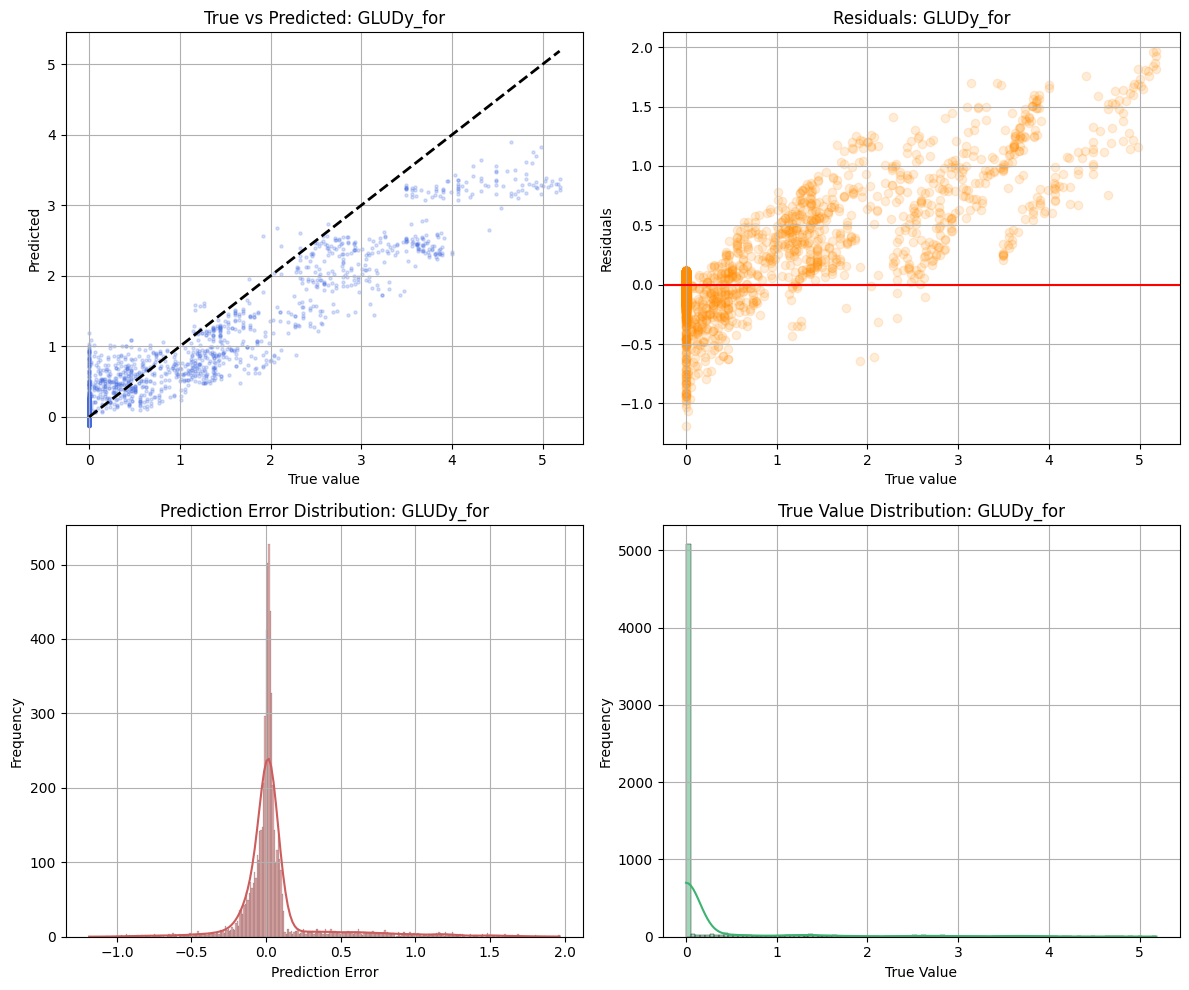

Number of parameters:
31502


In [54]:
train_losses_3242, test_losses_3242, model_3242, optimizer = train_model(d_model=32, n_heads=4, n_layers=2, d_ff=128, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_3242, test_losses_3242, d_model=32, n_heads=4, n_layers=2, d_ff=128)

plot_prediction_sample(X_test, y_test, model_3242)

for flux_name in diagnostics_to_plot:
    plot_flux(model_3242, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_3242.parameters() if p.requires_grad ))

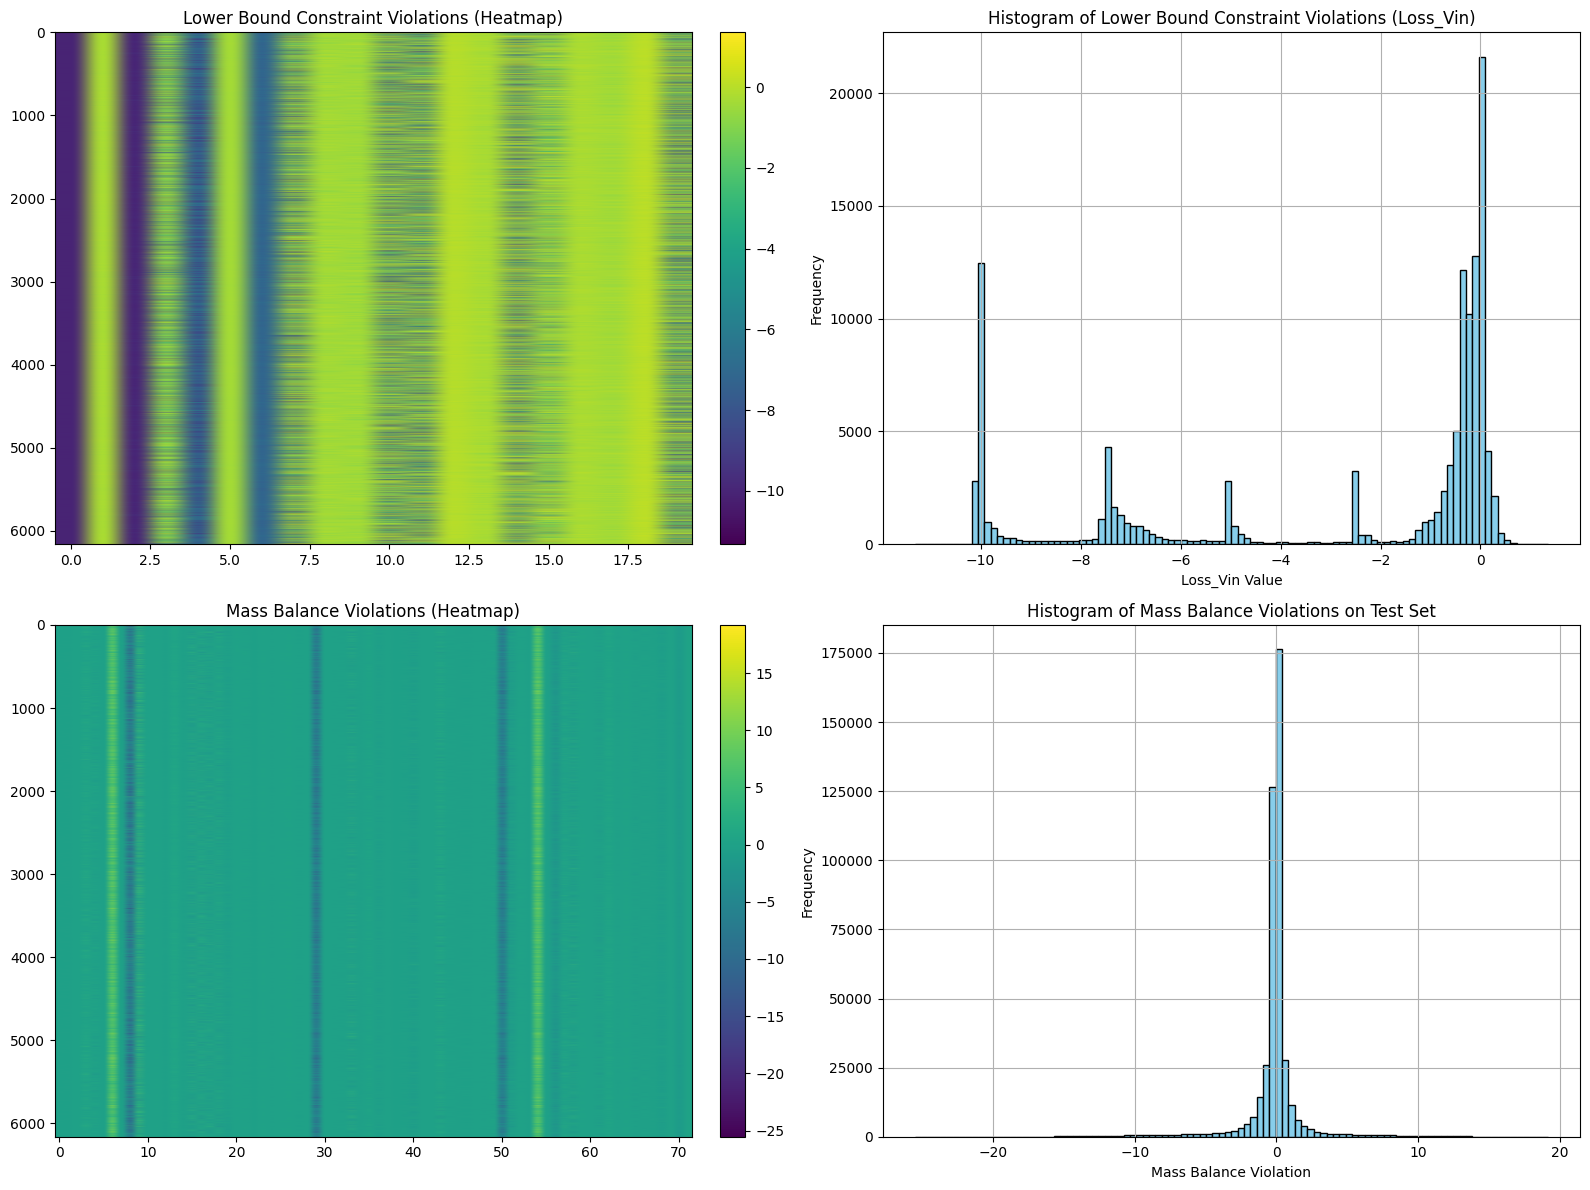

In [322]:
plot_constraint_and_mass_balance_diagnostics(model_3242, X_test, y_test, input_cols, data)

Epoch 2/200 | Train Loss: 2.568563 | Test Loss: 1.944593
Epoch 4/200 | Train Loss: 1.279328 | Test Loss: 1.197377
Epoch 4/200 | Train Loss: 1.279328 | Test Loss: 1.197377
Epoch 6/200 | Train Loss: 1.198194 | Test Loss: 1.109233
Epoch 6/200 | Train Loss: 1.198194 | Test Loss: 1.109233
Epoch 8/200 | Train Loss: 1.014158 | Test Loss: 0.978263
Epoch 8/200 | Train Loss: 1.014158 | Test Loss: 0.978263
Epoch 10/200 | Train Loss: 0.895004 | Test Loss: 0.830166
Epoch 10/200 | Train Loss: 0.895004 | Test Loss: 0.830166
Epoch 12/200 | Train Loss: 0.717322 | Test Loss: 0.684759
Epoch 12/200 | Train Loss: 0.717322 | Test Loss: 0.684759
Epoch 14/200 | Train Loss: 0.628974 | Test Loss: 0.576142
Epoch 14/200 | Train Loss: 0.628974 | Test Loss: 0.576142
Epoch 16/200 | Train Loss: 0.556885 | Test Loss: 0.473560
Epoch 16/200 | Train Loss: 0.556885 | Test Loss: 0.473560
Epoch 18/200 | Train Loss: 0.501146 | Test Loss: 0.458512
Epoch 18/200 | Train Loss: 0.501146 | Test Loss: 0.458512
Epoch 20/200 | Train 

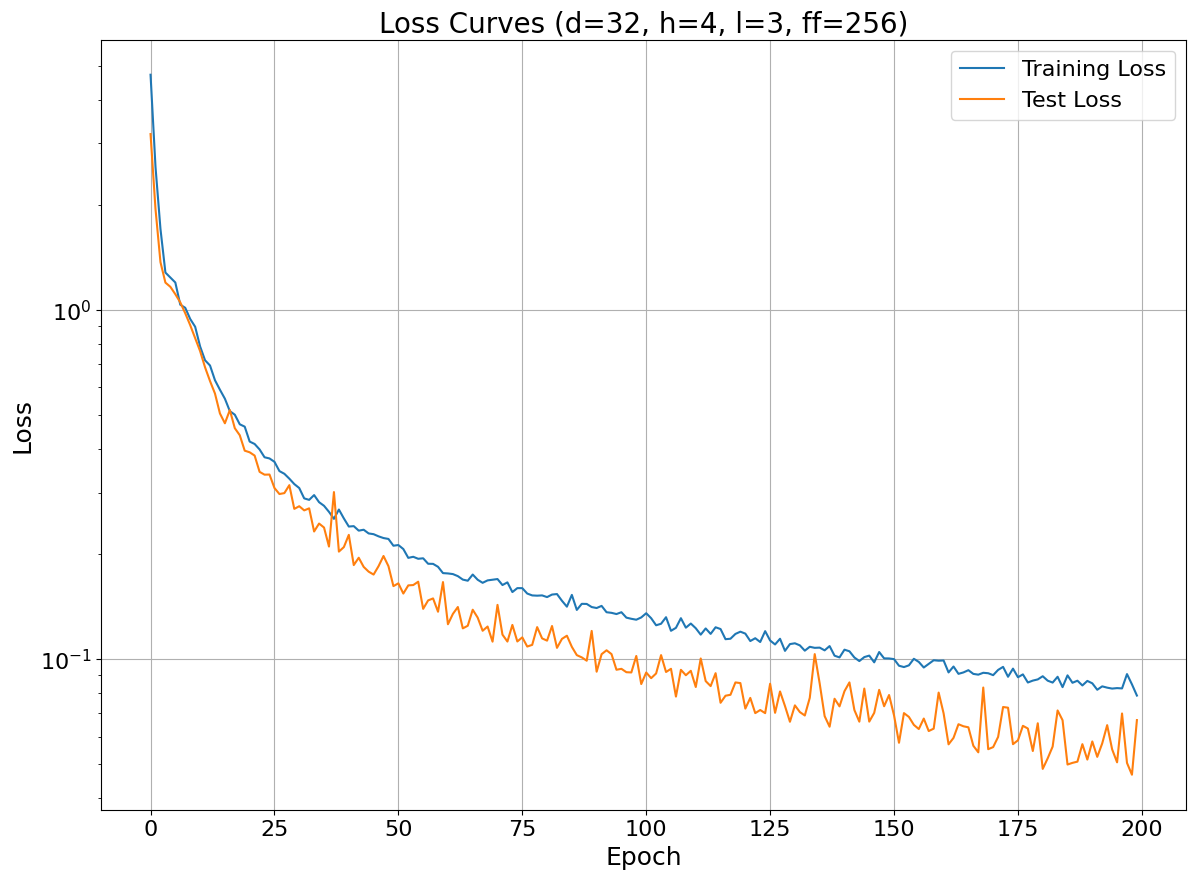

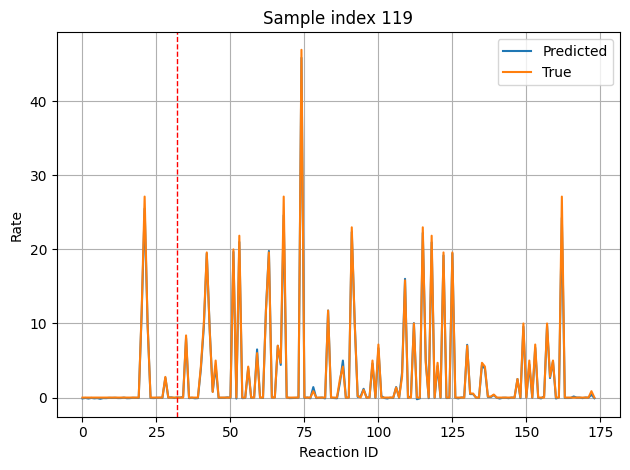

y_pred_outputs.shape: (6160, 154) min/max: -1.3630948 81.40785
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: 0.5590506 to 1.2481481
y_pred_outputs[:, _idx] range: 0.58528906 to 1.2066523


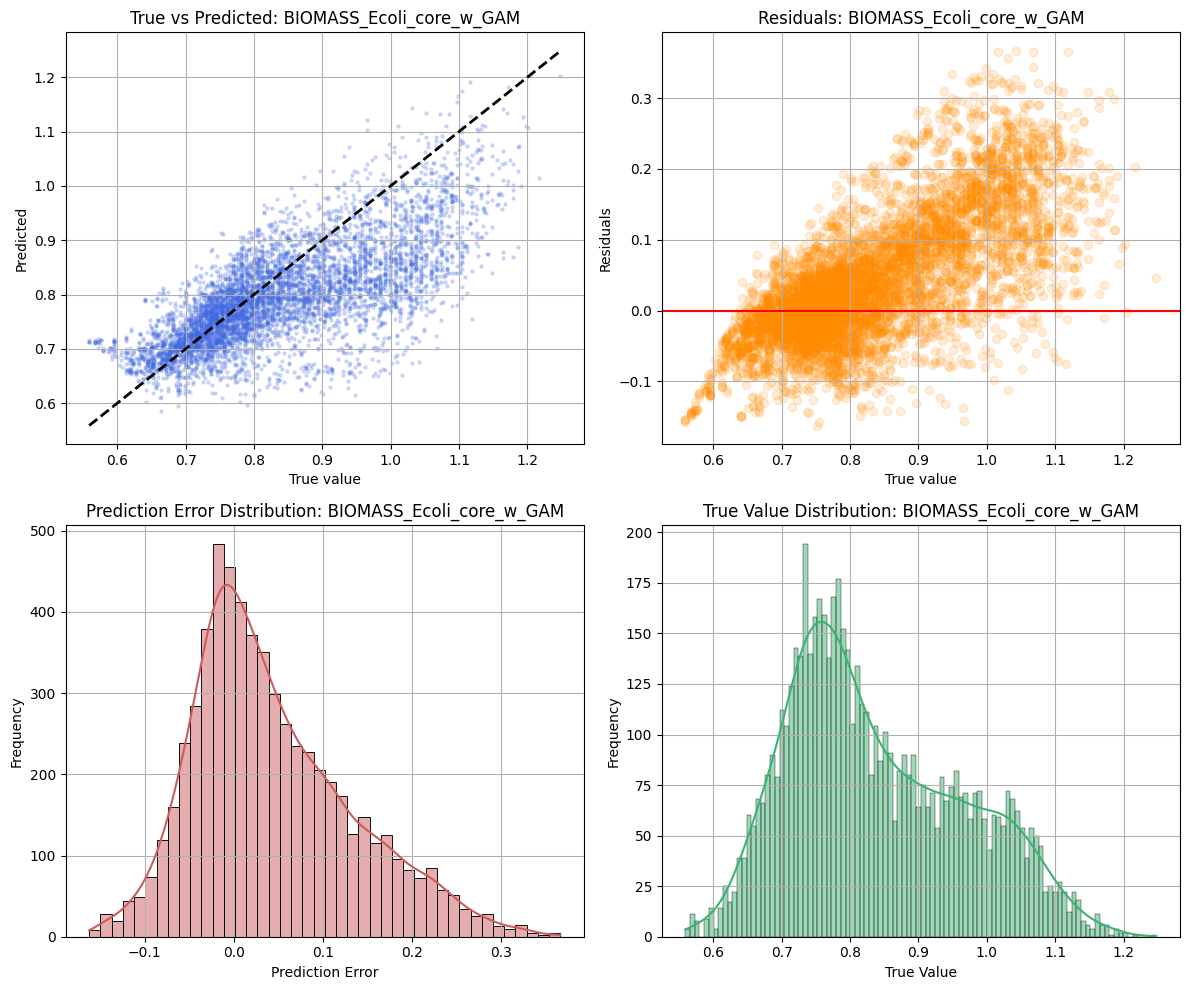

y_pred_outputs.shape: (6160, 154) min/max: -1.3630948 81.40785
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: 0.0 to 5.187185
y_pred_outputs[:, _idx] range: -0.12707907 to 3.797065


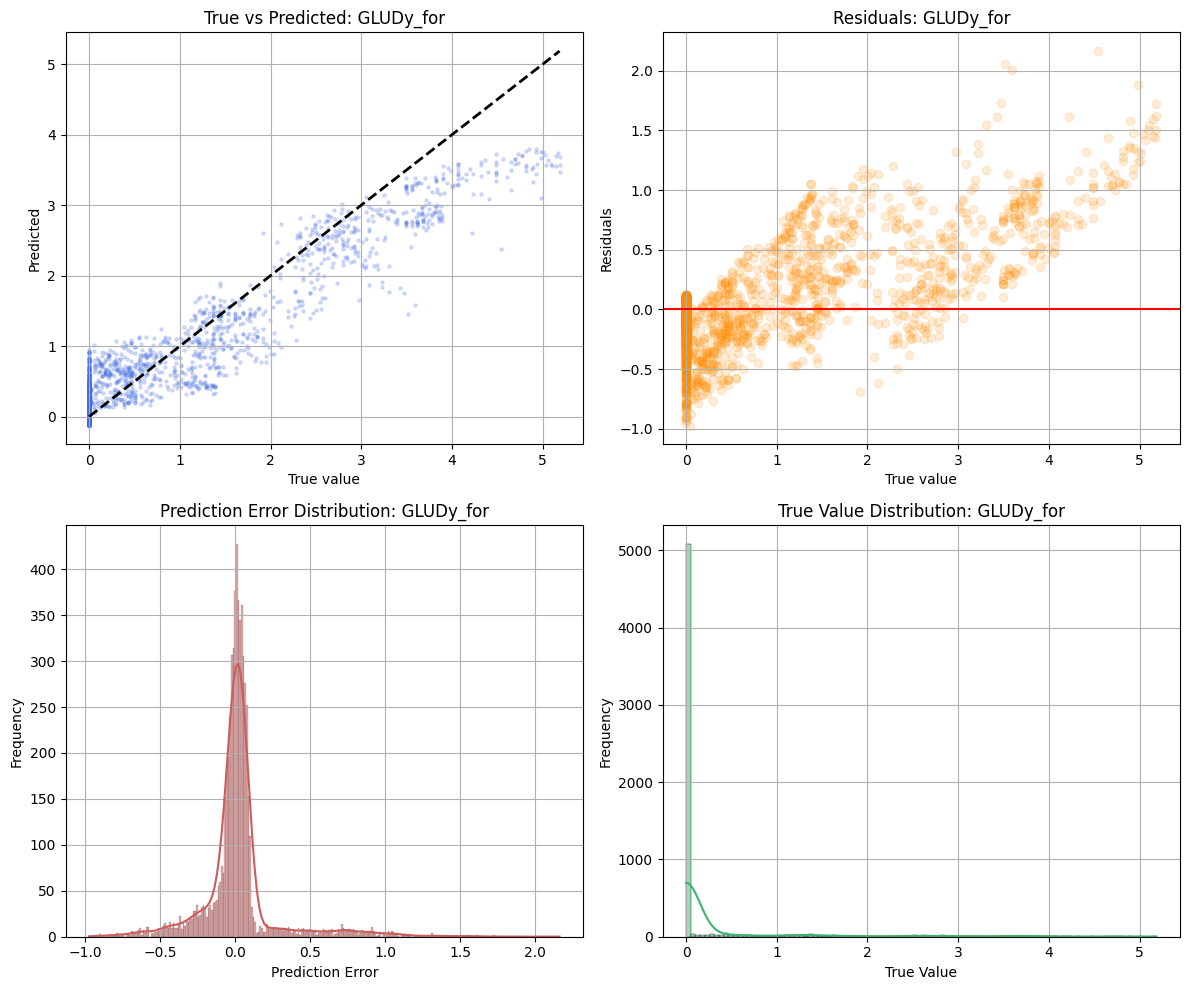

Number of parameters:
70197


In [316]:
train_losses_3243_256, test_losses_3243_256, model_3243_256, optimizer = train_model(d_model=32, n_heads=4, n_layers=3, d_ff=256, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_3243_256, test_losses_3243_256, d_model=32, n_heads=4, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_3243_256)

for flux_name in diagnostics_to_plot:
    plot_flux(model_3243_256, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_3243_256.parameters() if p.requires_grad ))

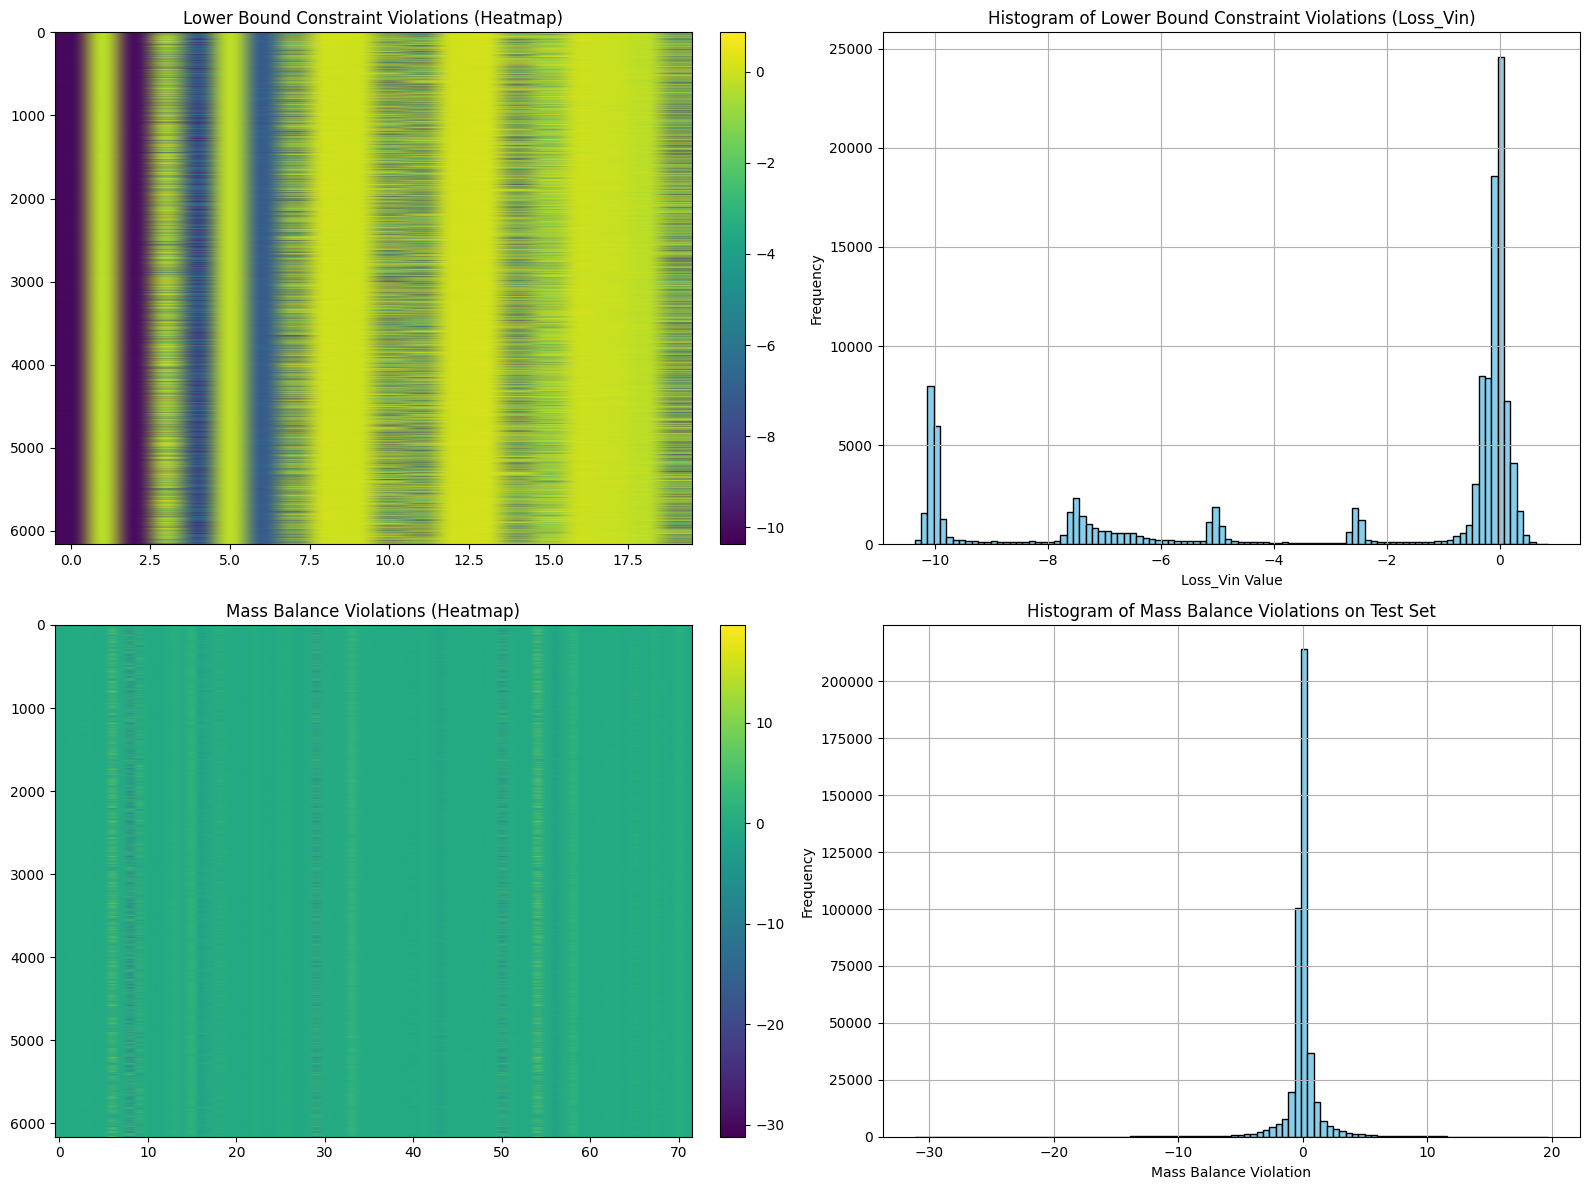

In [323]:
plot_constraint_and_mass_balance_diagnostics(model_3243_256, X_test, y_test, input_cols, data)

Epoch 2/200 | Train Loss: 1.552197 | Test Loss: 1.333836
Epoch 4/200 | Train Loss: 1.023710 | Test Loss: 0.922525
Epoch 4/200 | Train Loss: 1.023710 | Test Loss: 0.922525
Epoch 6/200 | Train Loss: 0.698751 | Test Loss: 0.626001
Epoch 6/200 | Train Loss: 0.698751 | Test Loss: 0.626001
Epoch 8/200 | Train Loss: 0.556958 | Test Loss: 0.514574
Epoch 8/200 | Train Loss: 0.556958 | Test Loss: 0.514574
Epoch 10/200 | Train Loss: 0.452802 | Test Loss: 0.406737
Epoch 10/200 | Train Loss: 0.452802 | Test Loss: 0.406737
Epoch 12/200 | Train Loss: 0.380728 | Test Loss: 0.318740
Epoch 12/200 | Train Loss: 0.380728 | Test Loss: 0.318740
Epoch 14/200 | Train Loss: 0.327000 | Test Loss: 0.263493
Epoch 14/200 | Train Loss: 0.327000 | Test Loss: 0.263493
Epoch 16/200 | Train Loss: 0.279290 | Test Loss: 0.219379
Epoch 16/200 | Train Loss: 0.279290 | Test Loss: 0.219379
Epoch 18/200 | Train Loss: 0.243761 | Test Loss: 0.226446
Epoch 18/200 | Train Loss: 0.243761 | Test Loss: 0.226446
Epoch 20/200 | Train 

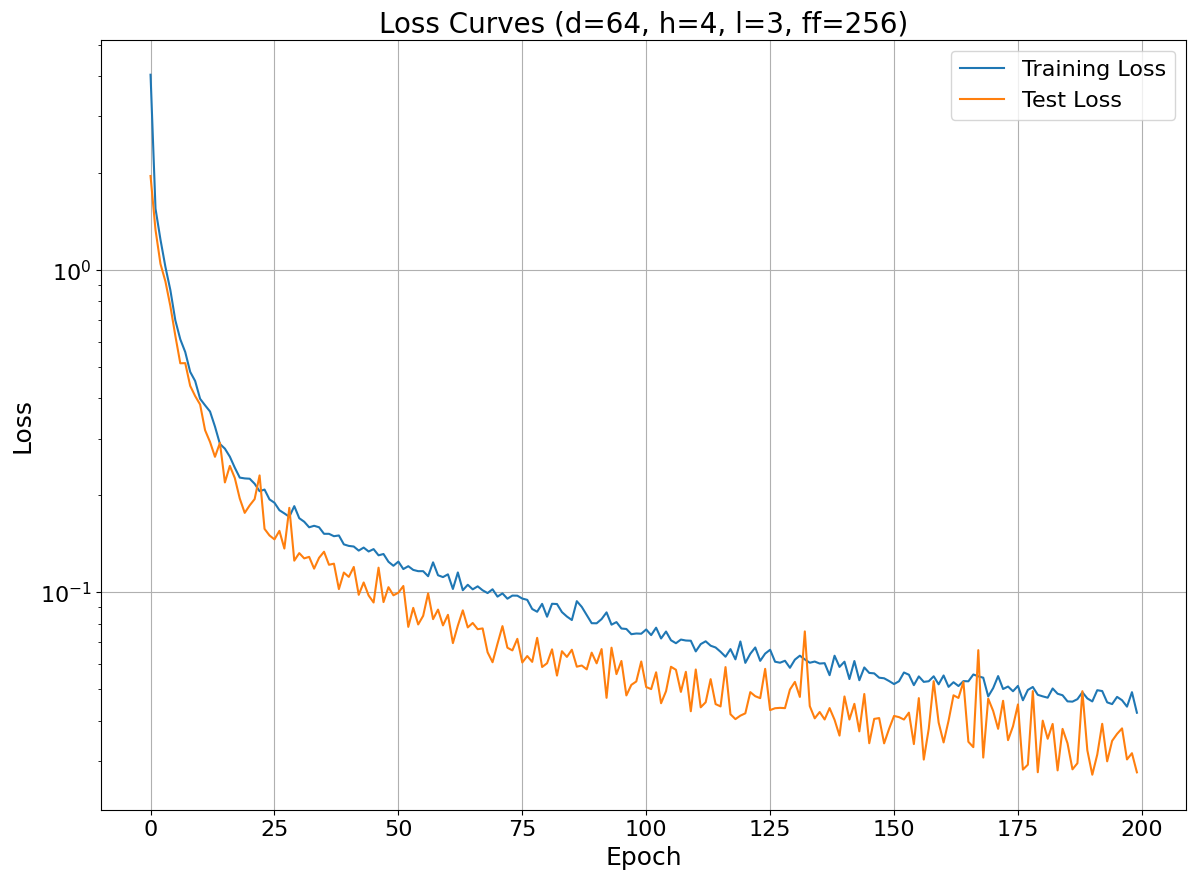

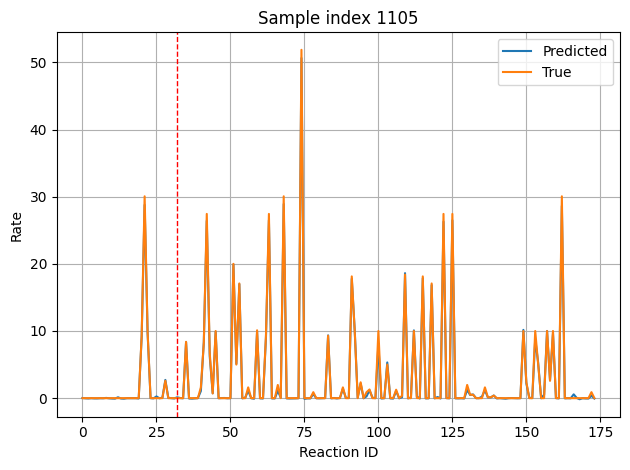

y_pred_outputs.shape: (6160, 154) min/max: -0.97909594 80.99562
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
BIOMASS_Ecoli_core_w_GAM index in outputs: 24
y_true_outputs[:, idx] range: 0.5590506 to 1.2481481
y_pred_outputs[:, _idx] range: 0.6047398 to 1.0822467


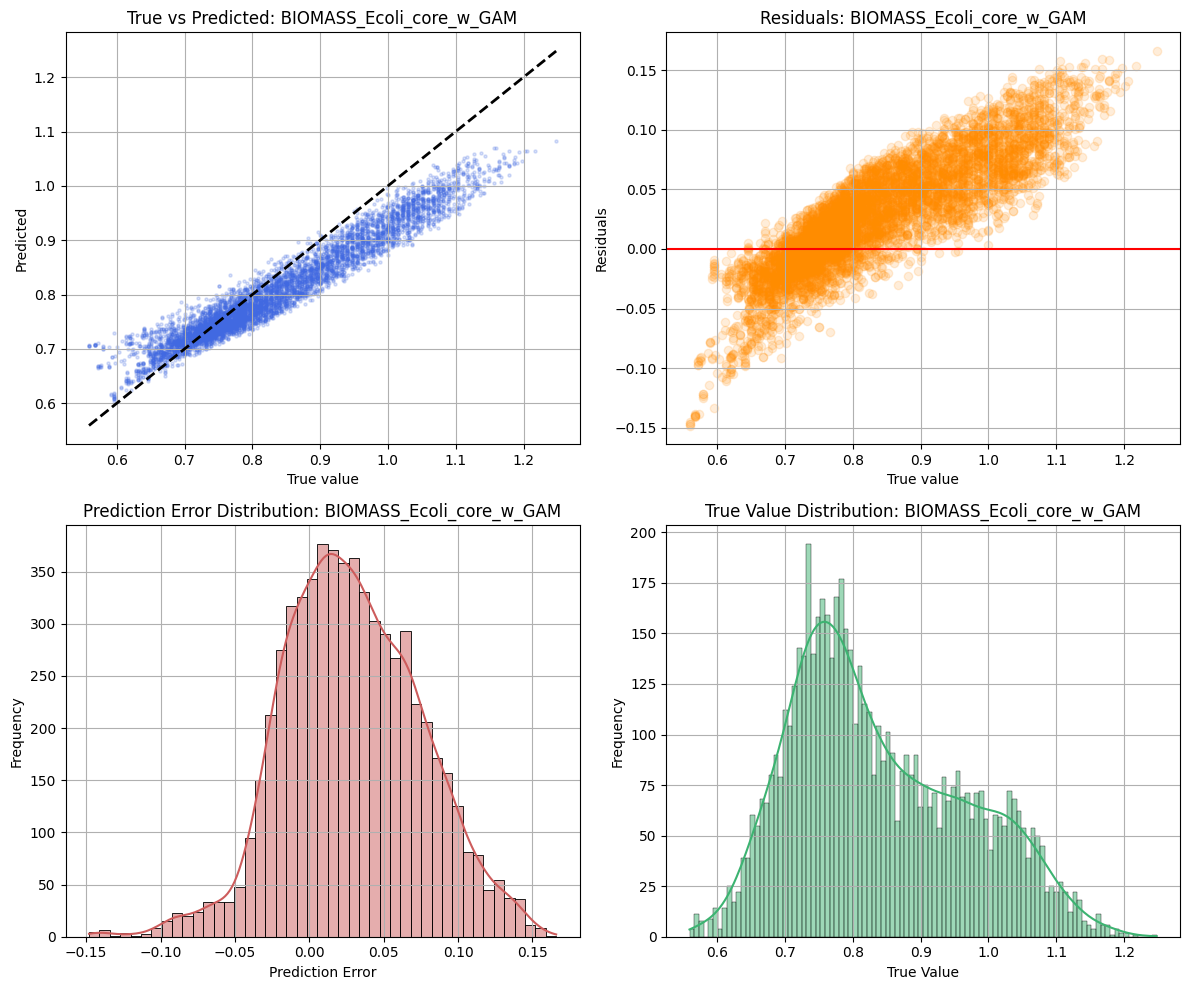

y_pred_outputs.shape: (6160, 154) min/max: -0.97909594 80.99562
y_true_outputs.shape: (6160, 154) min/max: 0.0 86.397766
GLUDy_for index in outputs: 75
y_true_outputs[:, idx] range: 0.0 to 5.187185
y_pred_outputs[:, _idx] range: -0.10574925 to 4.5780163


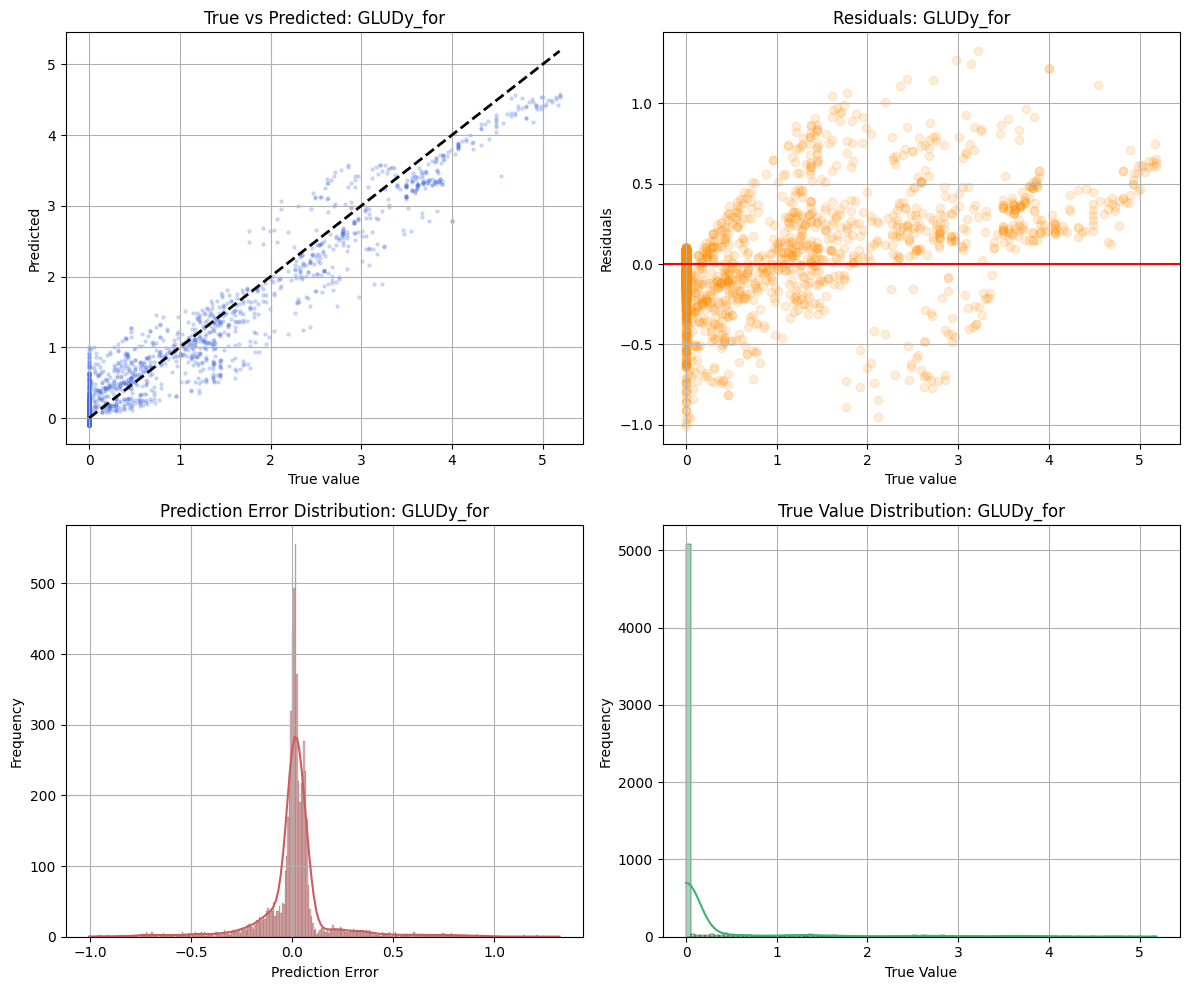

Number of parameters:
162645


In [324]:
train_losses_6443_256, test_losses_6443_256, model_6443_256, optimizer = train_model(d_model=64, n_heads=4, n_layers=3, d_ff=256, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_6443_256, test_losses_6443_256, d_model=64, n_heads=4, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_6443_256)

for flux_name in diagnostics_to_plot:
    plot_flux(model_6443_256, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_6443_256.parameters() if p.requires_grad ))

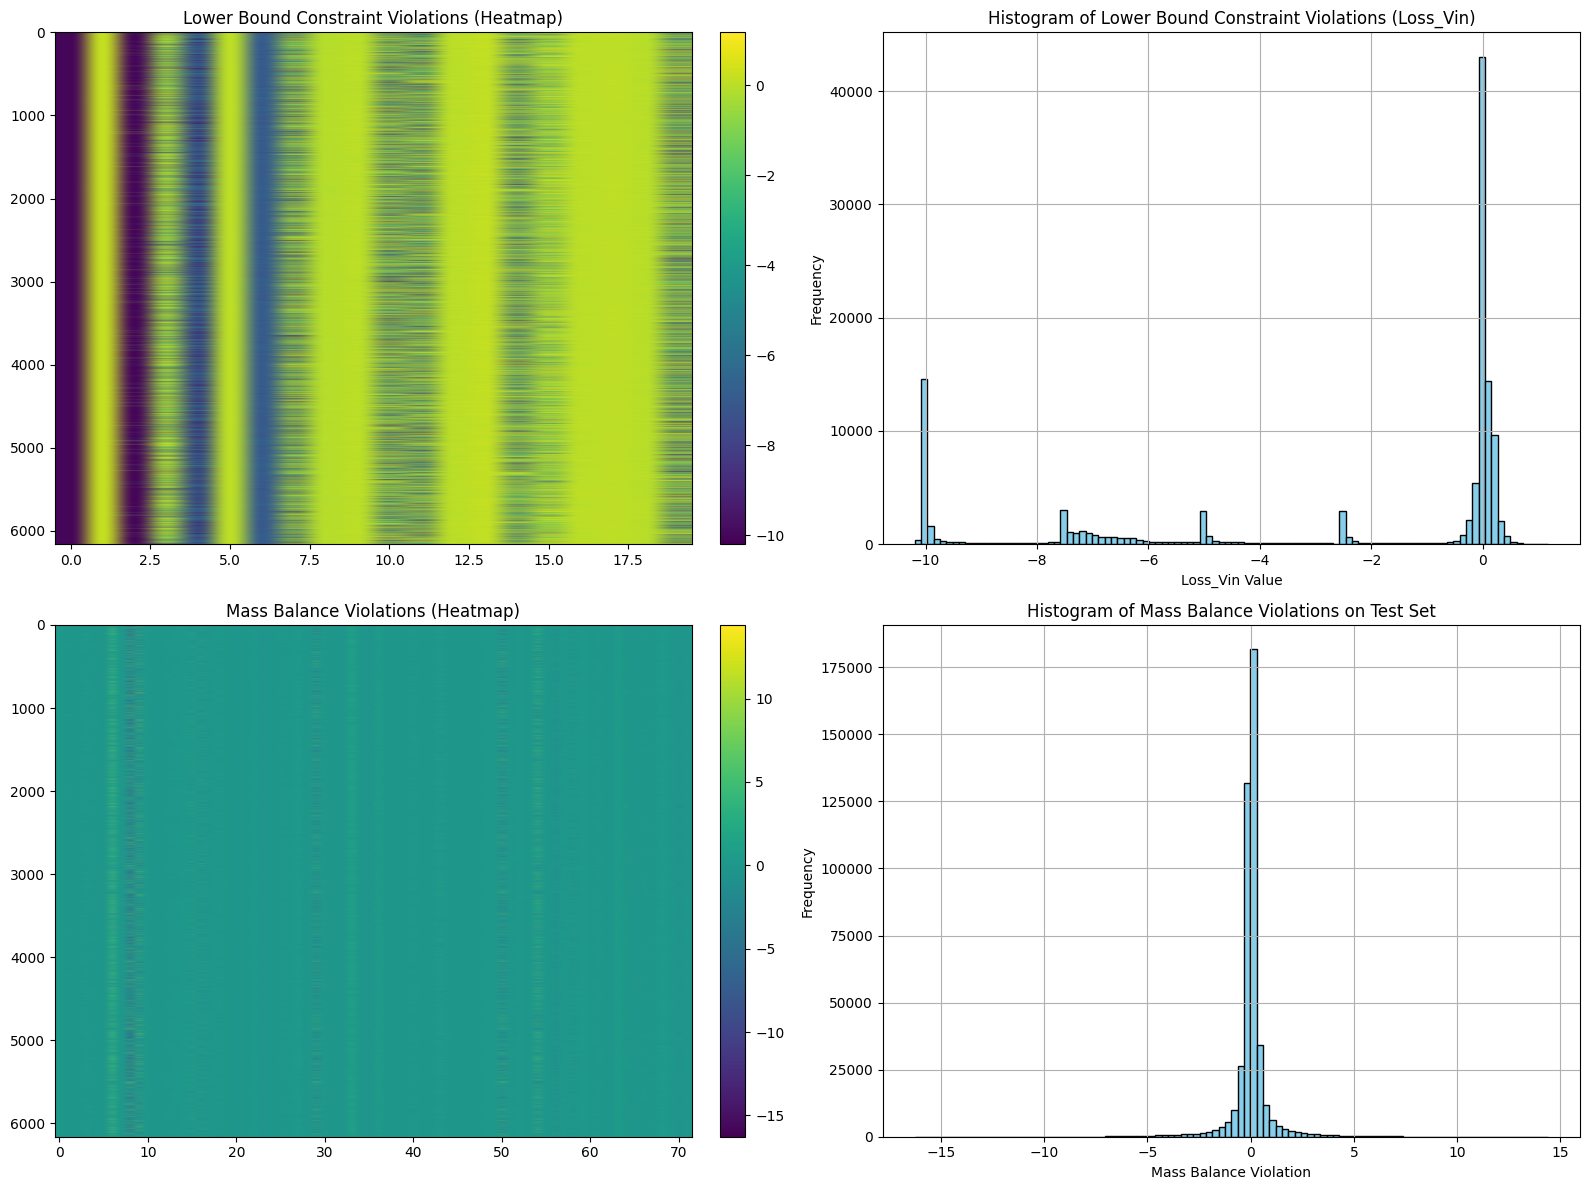

In [326]:
plot_constraint_and_mass_balance_diagnostics(model_6443_256, X_test, y_test, input_cols, data)

In [ ]:
train_losses_6483_256, test_losses_6483_256, model_6483_256, optimizer = train_model(d_model=64, n_heads=8, n_layers=3, d_ff=256, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_6483_256, test_losses_6483_256, d_model=64, n_heads=8, n_layers=3, d_ff=256)

plot_prediction_sample(X_test, y_test, model_6483_256)

for flux_name in diagnostics_to_plot:
    plot_flux(model_6483_256, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_6483_256.parameters() if p.requires_grad ))

In [ ]:

train_losses_6483_512, test_losses_6483_512, model_6483_512, optimizer = train_model(d_model=64, n_heads=8, n_layers=3, d_ff=512, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_6483_512, test_losses_6483_512, d_model=64, n_heads=8, n_layers=3, d_ff=512)

plot_prediction_sample(X_test, y_test, model_6483_512)

for flux_name in diagnostics_to_plot:
    plot_flux(model_6483_512, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_6483_512.parameters() if p.requires_grad ))

In [ ]:

train_losses_12842_512, test_losses_12842_512, model_12842_512, optimizer = train_model(d_model=128, n_heads=4, n_layers=2, d_ff=512, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_12842_512, test_losses_12842_512, d_model=128, n_heads=4, n_layers=2, d_ff=512)

plot_prediction_sample(X_test, y_test, model_12842_512)

for flux_name in diagnostics_to_plot:
    plot_flux(model_12842_512, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_12842_512.parameters() if p.requires_grad ))

In [ ]:

train_losses_12843_512, test_losses_12843_512, model_12843_512, optimizer = train_model(d_model=128, n_heads=4, n_layers=3, d_ff=512, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_12843_512, test_losses_12843_512, d_model=128, n_heads=4, n_layers=3, d_ff=512)

plot_prediction_sample(X_test, y_test, model_12843_512)

for flux_name in diagnostics_to_plot:
    plot_flux(model_12843_512, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_12843_512.parameters() if p.requires_grad ))

In [ ]:

train_losses_12883_512, test_losses_12883_512, model_12883_512, optimizer = train_model(d_model=128, n_heads=8, n_layers=3, d_ff=512, num_epochs=num_epochs, dropout=dropout)

plot_loss_curves(train_losses_12883_512, test_losses_12883_512, d_model=128, n_heads=8, n_layers=3, d_ff=512)

plot_prediction_sample(X_test, y_test, model_12883_512)

for flux_name in diagnostics_to_plot:
    plot_flux(model_12883_512, X_test, y_test, output_cols, flux_name)

print('Number of parameters:')
print(sum( p.numel() for p in model_12883_512.parameters() if p.requires_grad ))

In [ ]:
# model_configs = {'d_model':[
#                              8, 16, 32, 32, 64, 64, 64, 128, 128, 128
#                                 ], 
#                     'n_heads':[
#                             2, 2, 4, 4, 4, 8, 8, 4, 4, 8
#                             ], 
#                     'n_layers':[
#                             2, 2, 2, 3, 3, 3, 3, 2, 3, 3
#                             ], 
#                     'd_ff':[
#                             128, 128, 128, 256, 256, 256, 512, 512, 512, 512
#                             ]}

In [ ]:
# def plot_constraint_and_mass_balance_diagnostics(model, X_test, y_test, input_cols, data):
#     """
#     Runs the model on test data and generates:
#     1. Lower bound constraint violation heatmap
#     2. Histogram of lower bound violations
#     3. Mass balance violation heatmap
#     4. Histogram of mass balance violations
#     """
#     import torch
#     import matplotlib.pyplot as plt

#     # Move model to CPU and set to eval mode
#     model_cpu = model.to('cpu')
#     model_cpu.eval()

#     with torch.no_grad():
#         y_pred_tensor, _ = model_cpu(X_test.unsqueeze(-1).to('cpu'))

#     y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()
#     y_true_full = y_test.cpu().numpy()

#     Pin = torch.tensor(data['Pin'], dtype=torch.float32)
#     S = torch.tensor(data['S'], dtype=torch.float32)

#     # Lower bound constraint violations
#     Loss_Vin = torch.matmul(
#         y_pred_tensor[:, len(input_cols):, :].permute(0, 2, 1).to('cpu'),
#         Pin.T
#     ) - X_test.to('cpu').unsqueeze(1)[:, :, :len(input_cols)]
#     Loss_Vin_np = Loss_Vin.squeeze(1).cpu().numpy()

#     # Plot 1: Lower bound constraint violation heatmap
#     plt.imshow(Loss_Vin_np[:, -1, :], aspect='auto', cmap='viridis')
#     plt.colorbar(label='Lower bound Check (must be >= 0)')
#     plt.title('Lower Bound Constraint Violations (Heatmap)')
#     plt.show()

#     # Plot 2: Histogram of lower bound violations
#     plt.figure(figsize=(10, 6))
#     plt.hist(Loss_Vin_np[:, -1, :].flatten(), bins=100, color='skyblue', edgecolor='black')
#     plt.title('Histogram of Lower Bound Constraint Violations (Loss_Vin)')
#     plt.xlabel('Loss_Vin Value')
#     plt.ylabel('Frequency')
#     plt.grid(True)
#     plt.show()

#     # Mass balance constraint violations
#     Loss_SV = torch.matmul(
#         y_pred_tensor[:, len(input_cols):, :].permute(0, 2, 1).to('cpu'),
#         S.T
#     )
#     Loss_SV_np = Loss_SV.cpu().numpy()

#     # Plot 3: Mass balance violation heatmap
#     plt.imshow(Loss_SV_np[:, -1, :], aspect='auto', cmap='viridis')
#     plt.colorbar(label='Mass Balance Check (must be ~ 0)')
#     plt.title('Mass Balance Violations (Heatmap)')
#     plt.show()

#     # Plot 4: Histogram of mass balance violations
#     plt.figure(figsize=(10, 6))
#     plt.hist(Loss_SV_np[:, -1, :].flatten(), bins=100, color='skyblue', edgecolor='black')
#     plt.title('Histogram of Mass Balance Violations on Test Set')
#     plt.xlabel('Mass Balance Violation')
#     plt.ylabel('Frequency')
#     plt.grid(True)
#     plt.show()

In [ ]:

# def min_distance_to_null_space(S, v):
#     """
#     Computes the minimum Euclidean distance between a vector v and the null space of matrix S.
#     Returns the distance and the closest vector in the null space.
#     """
#     # Compute the null space of S using SVD
#     U, D, Vh = np.linalg.svd(S)
#     tol = 1e-12
#     null_mask = (D < tol)
#     null_space = Vh.T[:, D < tol] if np.any(null_mask) else Vh.T[:, len(D):]

#     if null_space.shape[1] == 0:
#         raise ValueError("Matrix S has trivial null space (only zero vector).")

#     # Project v onto the null space
#     # Find coefficients c that minimize ||v - N c||^2
#     N = null_space
#     c = np.linalg.lstsq(N, v, rcond=None)[0]
#     v_proj = N @ c

#     # Minimum distance
#     distance = np.linalg.norm(v - v_proj)
#     return distance, v_proj

# # Example usage:
# # S = ... # your stoichiometric matrix
# # v = ... # your vector
# # dist, closest_vec = min_distance_to_null_space(S, v)
# # print("Minimum distance:", dist)
# # print("Closest vector in null space:", closest_vec)